# Posterior Correlation Matrix Analysis for Cardiac Parameter Identification

## 背景与目标

在心肌力学参数的贝叶斯推断中，**equifinality**（等效终态性）是一个核心挑战：不同区域的参数组合可能产生几乎相同的心室整体力学响应，导致后验分布中参数之间出现强相关。本 notebook 通过系统分析 MCMC 后验样本中的相关结构，量化这种 equifinality 的程度及其与疾病严重程度的关系。

### 实验设计

| Scenario | 文件夹 | 描述 | 样本结构 |
|----------|--------|------|----------|
| HCM | `MVGP_HCM_mcmc_result` | 全局病变，5个区域参数均 ~ N(1.7) | 100个独立样本 |
| MI_1 | `MVGP_MI_1_mcmc_result` | 局部轻微病变，目标区域 ~ N(1.5)，其余 ~ N(1.0) | 5区域 × 20样本 |
| MI_2 | `MVGP_MI_2_mcmc_result` | 局部中度病变，目标区域 ~ N(2.0)，其余 ~ N(1.0) | 5区域 × 20样本 |
| MI_3 | `MVGP_MI_3_mcmc_result` | 局部较重病变，目标区域 ~ N(3.0)，其余 ~ N(1.0) | 5区域 × 20样本 |

### 分析流程

1. **数据加载与预处理** — 读取 pkl 文件，转换为 numpy 矩阵，记录 target region 信息
2. **10×10 全参数相关矩阵** — 最细粒度，看每个参数之间的耦合
3. **5×5 区域级相关矩阵** — 压缩为区域级别，更直观
4. **Per-target 分析** — MI 场景中按病变区域分组，揭示特异性耦合
5. **Distance-aligned 分析** — 按解剖距离重索引，提取距离依赖的通用模式
6. **严重程度趋势** — 相关强度随病变程度的变化
7. **稳定性筛选** — 哪些相关跨样本稳定存在
8. **统计检验** — 场景间相关差异的显著性

---
## 0. 环境配置与全局常量

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from matplotlib.colors import TwoSlopeNorm
from pathlib import Path
from typing import Dict, List, Tuple, Optional
from collections import Counter
import pickle
import warnings

# ── 出图风格 ──
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05,
})

%matplotlib inline

In [2]:
# ══════════════════════════════════════════════════════════════
# 全局常量 — 根据你的实验设计修改此处
# ══════════════════════════════════════════════════════════════

N_REGIONS = 5
PARAMS_PER_REGION = 2
N_PARAMS = N_REGIONS * PARAMS_PER_REGION  # 10

# 解剖区域标签（顺序与参数索引匹配）
# param_0,1 → Anterior | param_2,3 → Inferior | param_4,5 → Lateral
# param_6,7 → Septal   | param_8,9 → Apical
REGION_LABELS = ["Anterior", "Inferior", "Lateral", "Septal", "Apical"]
REGION_LABELS_SHORT = ["Ant", "Inf", "Lat", "Sep", "Apx"]

# 每个区域两个参数的名称（替换为你的实际参数名，如 contractility / stiffness）
PARAM_NAMES_PER_REGION = ["a", "b"]
FULL_PARAM_LABELS = [
    f"{REGION_LABELS_SHORT[r]}_{PARAM_NAMES_PER_REGION[p]}"
    for r in range(N_REGIONS)
    for p in range(PARAMS_PER_REGION)
]

# Scenario 配置
SCENARIOS = ["HCM", "MI_1", "MI_2", "MI_3"]
SCENARIO_TO_FOLDER = {
    "HCM":  "MVGP_HCM",
    "MI_1": "MVGP_MI_1",
    "MI_2": "MVGP_MI_2",
    "MI_3": "MVGP_MI_3",
}
SCENARIO_DISPLAY = {
    "HCM":  "HCM (Global, \u03bc=1.7)",
    "MI_1": "MI Mild (\u03bc=1.5)",
    "MI_2": "MI Moderate (\u03bc=2.0)",
    "MI_3": "MI Severe (\u03bc=3.0)",
}
LOCAL_MI_SCENARIOS = ["MI_1", "MI_2", "MI_3"]
SAMPLES_PER_TARGET = 20

# 解剖距离矩阵
#              Ant  Inf  Lat  Sep  Apx
DISTANCE_MATRIX = np.array([
    [0,   2,   1,   1,   1],   # Anterior
    [2,   0,   1,   1,   1],   # Inferior
    [1,   1,   0,   2,   1],   # Lateral
    [1,   1,   2,   0,   1],   # Septal
    [1,   1,   1,   1,   0],   # Apical
])
MAX_DISTANCE = int(DISTANCE_MATRIX.max())  # 2
DISTANCE_LABELS = ["Target"] + [f"Dist {d}" for d in range(1, MAX_DISTANCE + 1)]

# ══════════════════════════════════════════════════════════════
# 数据路径 — 修改为你的实际数据根目录
# ══════════════════════════════════════════════════════════════
DATA_ROOT = "LocalDisease/Result"   # <-- 修改此处
OUTPUT_DIR = "./figures"
REGION_METHOD = "pc1_fixed"  # 区域级归约方式: pc1_fixed(推荐) / pc1_data / mean_abs / first

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
print("Configuration loaded.")
print(f"Regions: {REGION_LABELS}")
print(f"Parameters per region: {PARAMS_PER_REGION} → {N_PARAMS} total")
print(f"Scenarios: {SCENARIOS}")

Configuration loaded.
Regions: ['Anterior', 'Inferior', 'Lateral', 'Septal', 'Apical']
Parameters per region: 2 → 10 total
Scenarios: ['HCM', 'MI_1', 'MI_2', 'MI_3']


---
## 1. 数据加载

### 功能说明

从各 scenario 文件夹中读取 `result_1.pkl` ~ `result_100.pkl`，每个 pkl 文件包含一条 MCMC chain（字典格式，键为 `param_0` ~ `param_9`，值为 GPU tensor）。加载时：
- 将 tensor 移至 CPU 并转为 numpy 数组，拼接为 `(n_mcmc, 10)` 矩阵
- 对 MI 场景，根据文件编号自动推断病变区域（1-20 → Anterior, 21-40 → Inferior, ...）

### 输出目的

打印每个 scenario 的加载概况（样本数、chain 长度），以及 MI 场景的 target 分布，**确认数据完整性和 target 分配正确性**。

In [3]:
def get_target_region(sample_idx_1based: int) -> int:
    """
    根据 1-based 的样本编号推断病变区域。
    Samples 1-20 → Region 0 (Anterior)
    Samples 21-40 → Region 1 (Inferior)
    ...
    Samples 81-100 → Region 4 (Apical)
    """
    return (sample_idx_1based - 1) // SAMPLES_PER_TARGET


def mcmc_dict_to_array(chain_dict: dict) -> np.ndarray:
    """
    将单条 MCMC chain 从字典格式转为 (n_mcmc, 10) 的 numpy 矩阵。
    自动处理 GPU tensor → CPU numpy 的转换。
    """
    arrays = []
    for i in range(N_PARAMS):
        t = chain_dict[f"param_{i}"]
        if hasattr(t, "cpu"):
            arrays.append(t.cpu().numpy())
        else:
            arrays.append(np.asarray(t))
    return np.column_stack(arrays)


def load_all_chains(data_root, scenarios=SCENARIOS, n_samples=100):
    """
    加载所有 scenario 的 MCMC chains。
    
    返回:
        all_chains: dict[scenario] → list of (n_mcmc, 10) arrays
        target_regions: dict[scenario] → list of target region indices (None for HCM)
    """
    root = Path(data_root)
    all_chains = {}
    target_regions = {}

    for scenario in scenarios:
        folder_name = f"{SCENARIO_TO_FOLDER[scenario]}_mcmc_result"
        folder_path = root / folder_name

        if not folder_path.exists():
            print(f"WARNING: folder not found, skipping: {folder_path}")
            continue

        chains, targets = [], []
        for idx in range(1, n_samples + 1):
            pkl_path = folder_path / f"result_{idx}.pkl"
            if not pkl_path.exists():
                print(f"  WARNING: missing {pkl_path}")
                continue
            with open(pkl_path, "rb") as f:
                chains.append(mcmc_dict_to_array(pickle.load(f)))
            targets.append(get_target_region(idx) if scenario in LOCAL_MI_SCENARIOS else None)

        print(f"\u2705 {scenario} ({folder_name}): {len(chains)} samples, "
              f"chain length = {chains[0].shape[0] if chains else '?'}")

        if scenario in LOCAL_MI_SCENARIOS:
            dist = Counter(targets)
            print(f"   Target distribution: "
                  + ", ".join(f"{REGION_LABELS[r]}={dist[r]}" for r in sorted(dist)))

        all_chains[scenario] = chains
        target_regions[scenario] = targets

    return all_chains, target_regions


def group_chains_by_target(chains, targets):
    """
    将 MI 场景的 100 条 chain 按 target region 分为 5 组（各 20 条）。
    返回 dict[target_region] → list of chains
    """
    grouped = {r: [] for r in range(N_REGIONS)}
    for chain, target in zip(chains, targets):
        if target is not None:
            grouped[target].append(chain)
    return grouped

In [4]:
# 执行加载
all_chains, target_regions = load_all_chains(DATA_ROOT)

✅ HCM (MVGP_HCM_mcmc_result): 100 samples, chain length = 1200
✅ MI_1 (MVGP_MI_1_mcmc_result): 100 samples, chain length = 1200
   Target distribution: Anterior=20, Inferior=20, Lateral=20, Septal=20, Apical=20
✅ MI_2 (MVGP_MI_2_mcmc_result): 100 samples, chain length = 1200
   Target distribution: Anterior=20, Inferior=20, Lateral=20, Septal=20, Apical=20
✅ MI_3 (MVGP_MI_3_mcmc_result): 100 samples, chain length = 1200
   Target distribution: Anterior=20, Inferior=20, Lateral=20, Septal=20, Apical=20


---
## 2. 相关矩阵计算核心函数

### 功能说明

本 cell 定义所有相关矩阵的计算基础函数：

- **`compute_full_posterior_corr`**: 对单条 MCMC chain，计算 10 个参数的 10×10 Pearson 相关矩阵。
- **`compute_region_level_corr`**: 将 10×10 矩阵压缩为 5×5（传统 block 归约方法）。
- **`compute_region_level_corr_pc1`** ⭐: 通过区域内 PCA 降维实现 10D→5D 的投影，然后直接算 Pearson 相关。**推荐方法**，详见 Section 2b 的论证。
- **`aggregate_correlations`**: 对同一 scenario 下的 N 条 chain 各自计算相关矩阵，取 element-wise 均值和标准差。支持所有方法。

### 为什么推荐 PC1 投影法？

从 10×10 热力图可以观察到，每个区域内的两个参数 (a, b) 存在 **~-0.95 的强负相关**。以 Anterior ↔ Septal 的 2×2 block 为例：

```
            Sep_a    Sep_b
  Ant_a    -0.69    +0.64
  Ant_b    +0.61    -0.56
```

这是一个棋盘格符号模式（对角负、反对角正），说明 Anterior 和 Septal 沿**相反方向**调整参数——即 **补偿性耦合**。

传统的 `mean_abs` 方法对四个值取绝对值平均得到 **+0.62**，**丢失了补偿方向的符号信息**。PC1 投影法将每个区域的 (a, b) 投影到主成分方向 (a−b)/√2 上，然后在 5 个投影分数之间算 Pearson 相关，结果为 **-0.62**，正确反映了补偿关系。

### 下一个 cell 的输出目的

逐 scenario 绘制 10×10 全参数相关热力图，这是最完整的相关信息。适合作为论文 supplementary material。


In [5]:
def compute_full_posterior_corr(samples):
    """单条 chain 的 10×10 Pearson 相关矩阵。"""
    return np.corrcoef(samples, rowvar=False)


def compute_region_level_corr(samples, method="mean_abs"):
    """
    传统方法：将 10×10 相关矩阵压缩为 5×5 区域级矩阵。
    对每对区域 (i,j)，提取 2×2 block 并用指定方法归约为标量。
    注意：mean_abs 会丢失符号信息（补偿性耦合会被报告为正值）。
    """
    full_corr = compute_full_posterior_corr(samples)
    region_corr = np.zeros((N_REGIONS, N_REGIONS))
    for i in range(N_REGIONS):
        for j in range(N_REGIONS):
            rows = slice(i * PARAMS_PER_REGION, (i + 1) * PARAMS_PER_REGION)
            cols = slice(j * PARAMS_PER_REGION, (j + 1) * PARAMS_PER_REGION)
            block = full_corr[rows, cols]
            if i == j:
                region_corr[i, j] = 1.0
                continue
            if method == "mean_abs":
                region_corr[i, j] = np.mean(np.abs(block))
            elif method == "max_abs":
                region_corr[i, j] = np.max(np.abs(block))
            elif method == "frobenius":
                region_corr[i, j] = np.linalg.norm(block, "fro") / PARAMS_PER_REGION
            elif method == "first":
                region_corr[i, j] = block[0, 0]
    return region_corr


def compute_region_level_corr_pc1(samples, fixed_direction=True):
    """
    推荐方法：通过区域内 PCA 降维，将 10 参数投影为 5 个 PC1 得分，
    然后直接算 Pearson 相关。
    
    每个区域的 a, b 参数高度负相关（~-0.95），PC1 解释 ~97% 方差，
    方向近似恒定为 (1, -1)/√2，即 PC1 ≈ (a - b) / √2。
    
    优势相比 mean_abs:
    - 保留相关符号（补偿性耦合为负，协同耦合为正）
    - 结果是正式的 Pearson 相关矩阵（正半定）
    - 利用了两个参数的全部信息
    
    Parameters
    ----------
    samples : (n_mcmc, 10)
    fixed_direction : bool
        True  → 固定投影方向 (1, -1)/√2（推荐，无随机性）
        False → 每条 chain 数据驱动估计 PC1 方向
    """
    n_mcmc = samples.shape[0]
    pc1_scores = np.zeros((n_mcmc, N_REGIONS))
    
    if fixed_direction:
        direction = np.array([1.0, -1.0]) / np.sqrt(2)
    
    for r in range(N_REGIONS):
        region_data = samples[:, r*2:(r+1)*2]
        centered = region_data - region_data.mean(axis=0)
        if fixed_direction:
            pc1_scores[:, r] = centered @ direction
        else:
            U, S, Vt = np.linalg.svd(centered, full_matrices=False)
            pc1_dir = Vt[0]
            if pc1_dir[0] < 0:  # 固定符号：a 的 loading 为正
                pc1_dir = -pc1_dir
            pc1_scores[:, r] = centered @ pc1_dir
    
    return np.corrcoef(pc1_scores, rowvar=False)


def aggregate_correlations(chains, level="full", region_method="pc1_fixed"):
    """
    对 N 条 chain 各自计算相关矩阵，返回 element-wise 均值和标准差。
    
    level='full'   → 10×10
    level='region' → 5×5
        region_method: 'pc1_fixed'(推荐) / 'pc1_data' / 'mean_abs' / 'first' 等
    """
    corr_stack = []
    for chain in chains:
        if level == "full":
            corr_stack.append(compute_full_posterior_corr(chain))
        elif level == "region":
            if region_method == "pc1_fixed":
                corr_stack.append(compute_region_level_corr_pc1(chain, fixed_direction=True))
            elif region_method == "pc1_data":
                corr_stack.append(compute_region_level_corr_pc1(chain, fixed_direction=False))
            else:
                corr_stack.append(compute_region_level_corr(chain, method=region_method))
    corr_stack = np.array(corr_stack)
    return corr_stack.mean(axis=0), corr_stack.std(axis=0)


def _mask_diagonal(corr):
    """对角线设为 NaN，热力图中渲染为空白。"""
    masked = corr.copy()
    np.fill_diagonal(masked, np.nan)
    return masked


def plot_full_10x10_with_blocks(mean_corr, std_corr, title="", save_path=None):
    """
    10×10 热力图，粗黑线标出 5 个区域的 2×2 block 边界。
    """
    fig, ax = plt.subplots(figsize=(8, 7))
    norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
    data = _mask_diagonal(mean_corr)
    sns.heatmap(
        data, ax=ax, cmap="RdBu_r", norm=norm, annot=True, fmt=".2f",
        xticklabels=FULL_PARAM_LABELS, yticklabels=FULL_PARAM_LABELS,
        linewidths=0.3, linecolor="white", square=True,
        mask=np.isnan(data),
        cbar_kws={"label": "Correlation", "shrink": 0.75},
    )
    for k in range(1, N_REGIONS):
        pos = k * PARAMS_PER_REGION
        ax.axhline(pos, color="black", linewidth=1.5)
        ax.axvline(pos, color="black", linewidth=1.5)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=45)
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path)
    plt.show()
    plt.close(fig)



HCM (Global, μ=1.7)


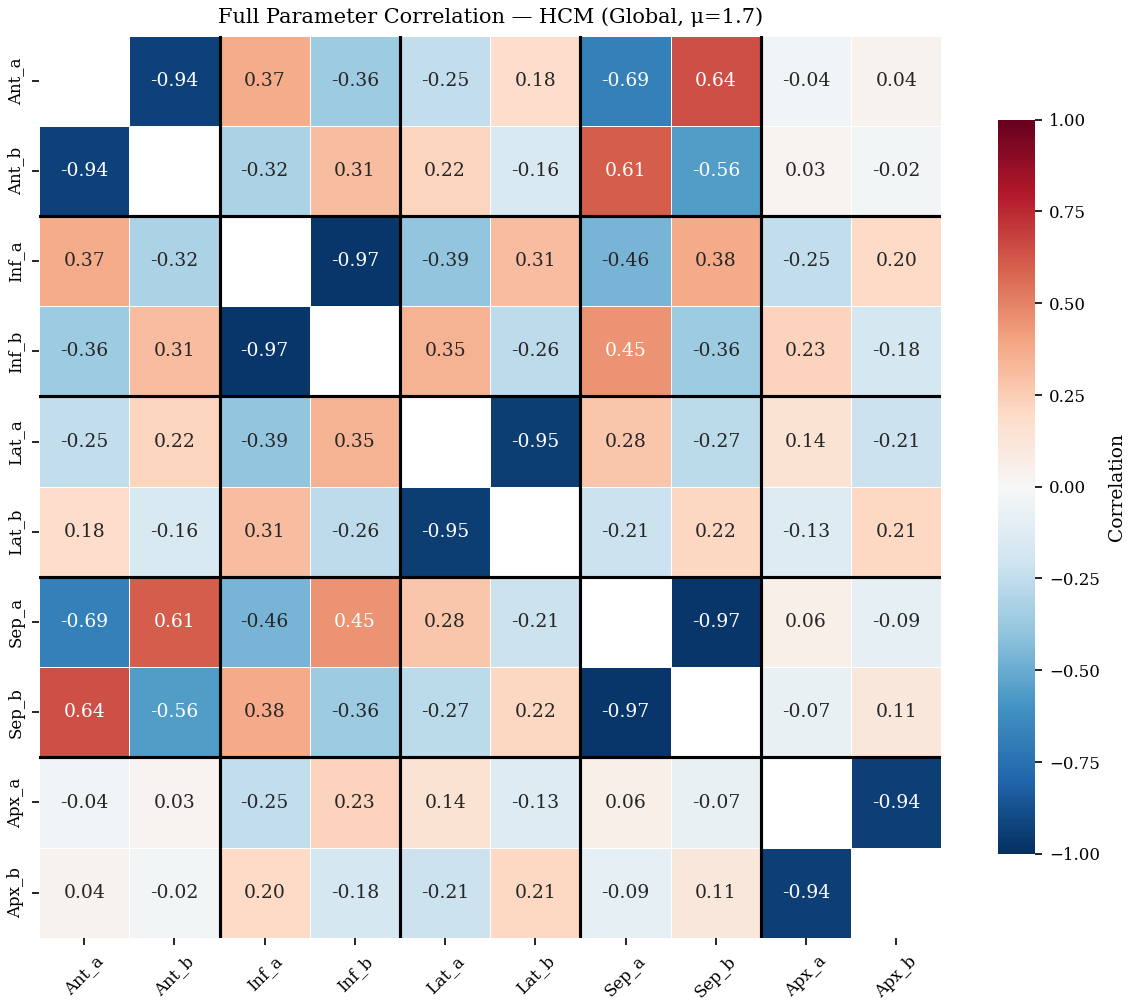


MI Mild (μ=1.5)


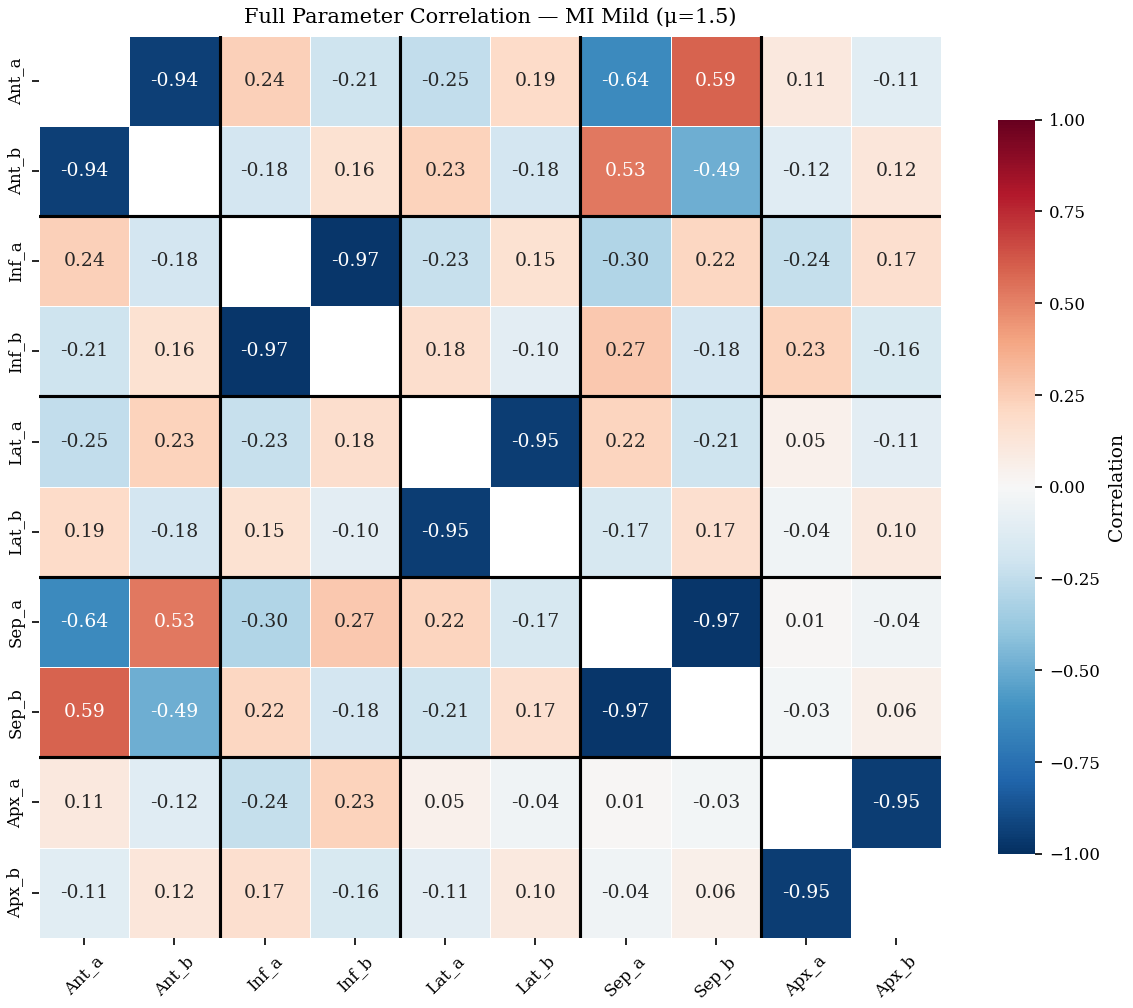


MI Moderate (μ=2.0)


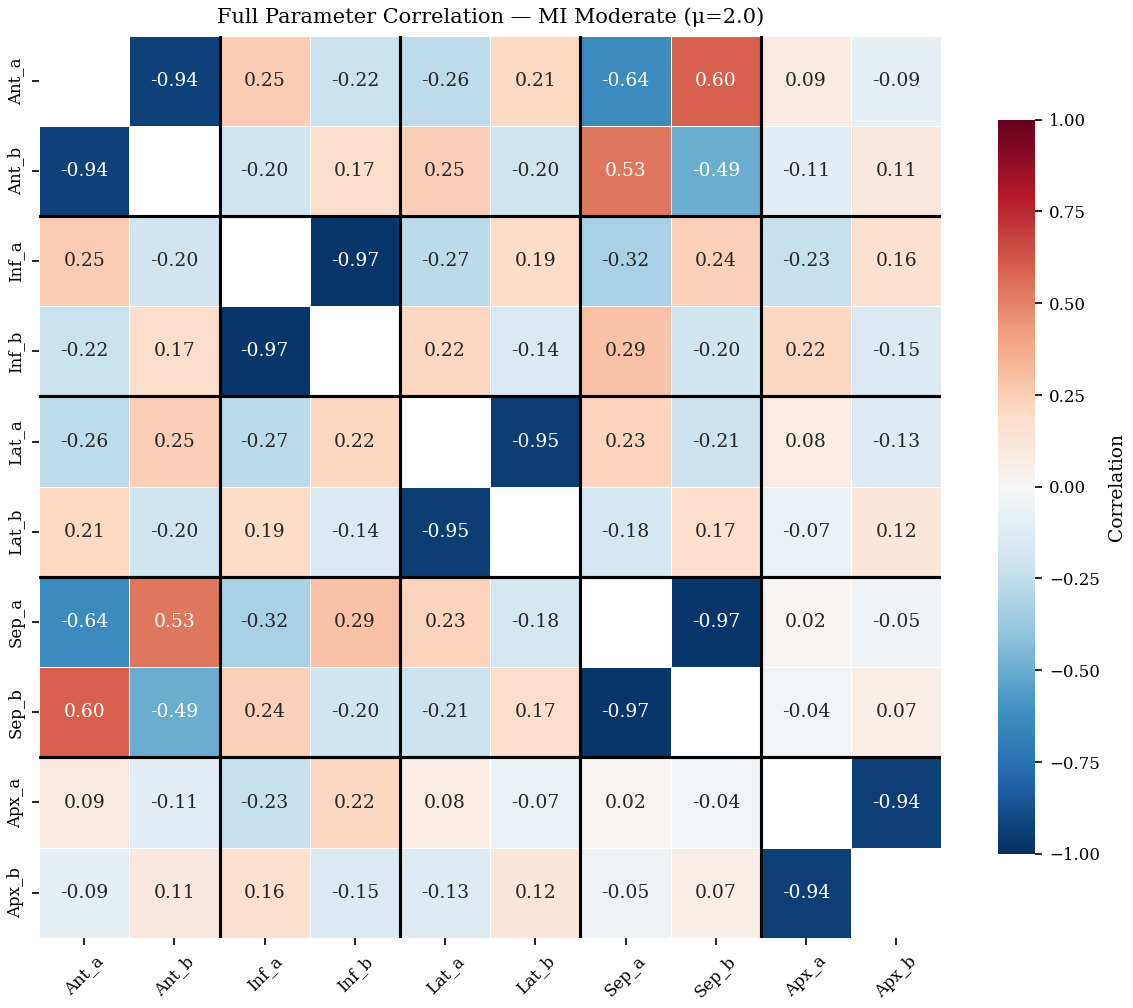


MI Severe (μ=3.0)


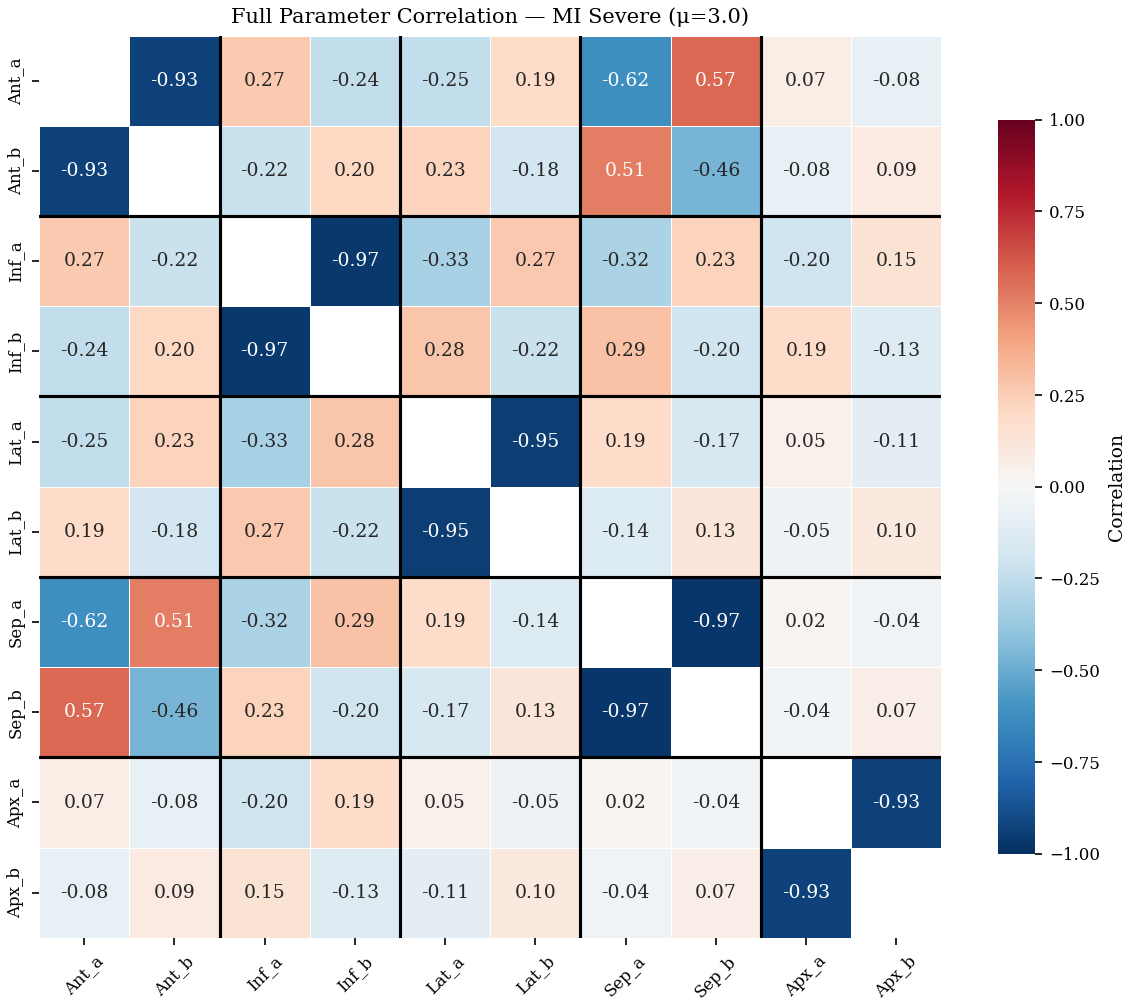

In [6]:
# 计算并绘制每个 scenario 的 10×10 相关矩阵
full_results = {}
for scenario, chains in all_chains.items():
    mean_c, std_c = aggregate_correlations(chains, level="full")
    full_results[scenario] = (mean_c, std_c)
    print(f"\n{'='*60}")
    print(f"{SCENARIO_DISPLAY.get(scenario, scenario)}")
    print(f"{'='*60}")
    plot_full_10x10_with_blocks(
        mean_c, std_c,
        title=f"Full Parameter Correlation — {SCENARIO_DISPLAY.get(scenario, scenario)}",
        # save_path=f"{OUTPUT_DIR}/full_10x10_{scenario}.png",
    )

---
## 2b. 区域内 PCA 验证与方法对比

### 为什么需要改进区域归约方法？

上方 10×10 热力图揭示了两个关键结构：

1. **区域内**：每个区域的 a 和 b 参数之间存在 **~-0.95 的极强负相关**（对角 block 中深蓝色），说明区域内两个参数存在固有的补偿机制。
2. **跨区域（以 Ant↔Sep 为例）**：2×2 block 呈棋盘格模式（对角负、反对角正），说明两个区域沿相反方向调整参数——这是 **补偿性** equifinality。

传统的 `mean_abs` 方法对 2×2 block 取绝对值平均，会把 Ant↔Sep 的补偿性耦合（真实值约 -0.6）报告为 +0.6，**丢失了关键的方向信息**。

### PC1 投影法

既然每个区域的两个参数高度负相关，我们可以用 **PCA 降维**将 2D → 1D：
- PC1 方向 ≈ (1, −1)/√2，即 PC1 得分 ≈ (a − b)/√2
- PC1 解释方差比应 >97%

然后在 5 个区域的 PC1 得分之间计算 Pearson 相关，得到正式的 5×5 相关矩阵。这种方法**保留了符号信息**，且结果是正半定矩阵。

### 以下两个 cell

1. **验证 PC1 有效性**：确认所有 scenario 中 PC1 解释方差 >95%，且区域内 corr(a,b) 确实 ~-0.95
2. **方法对比**：并排展示 `mean_abs`（旧）、`first`（只用 param a）、`PC1 fixed`（推荐）三种方法的热力图，直观对比差异


In [7]:
# ── PC1 有效性验证 ──
print("PC1 Explained Variance Ratio & Intra-region Correlation")
print("=" * 60)
print("(PC1 EVR > 0.95 且 corr(a,b) < -0.90 → 降维合理)\n")

for scenario, chains in all_chains.items():
    evrs, intra_corrs = [], []
    for chain in chains:
        for r in range(N_REGIONS):
            rd = chain[:, r*2:(r+1)*2]
            centered = rd - rd.mean(axis=0)
            _, S, _ = np.linalg.svd(centered, full_matrices=False)
            evrs.append(S[0]**2 / (S**2).sum())
            intra_corrs.append(np.corrcoef(rd, rowvar=False)[0, 1])
    evrs = np.array(evrs)
    intra_corrs = np.array(intra_corrs)
    print(f"  {SCENARIO_DISPLAY.get(scenario, scenario)}:")
    print(f"    PC1 explained variance: {evrs.mean():.4f} ± {evrs.std():.4f}")
    print(f"    Intra-region corr(a,b): {intra_corrs.mean():.3f} ± {intra_corrs.std():.3f}")

print("\n✅ 结论: PC1 解释 >97% 方差，(a,b) 之间 ~-0.95 负相关，")
print("   使用固定方向 (1,-1)/√2 的 PC1 投影完全合理。")


PC1 Explained Variance Ratio & Intra-region Correlation
(PC1 EVR > 0.95 且 corr(a,b) < -0.90 → 降维合理)

  HCM (Global, μ=1.7):
    PC1 explained variance: 0.9794 ± 0.0080
    Intra-region corr(a,b): -0.954 ± 0.015
  MI Mild (μ=1.5):
    PC1 explained variance: 0.9791 ± 0.0085
    Intra-region corr(a,b): -0.956 ± 0.016
  MI Moderate (μ=2.0):
    PC1 explained variance: 0.9787 ± 0.0085
    Intra-region corr(a,b): -0.955 ± 0.017
  MI Severe (μ=3.0):
    PC1 explained variance: 0.9770 ± 0.0101
    Intra-region corr(a,b): -0.950 ± 0.022

✅ 结论: PC1 解释 >97% 方差，(a,b) 之间 ~-0.95 负相关，
   使用固定方向 (1,-1)/√2 的 PC1 投影完全合理。


In [ ]:
# ── 方法对比面板 ──
def compare_methods_panel(chains, scenario_name):
    """并排展示三种方法的 5×5 热力图。"""
    methods = {
        "mean_abs (旧方法)": lambda c: compute_region_level_corr(c, method="mean_abs"),
        "first (只用 param a)": lambda c: compute_region_level_corr(c, method="first"),
        "PC1 fixed (推荐)": lambda c: compute_region_level_corr_pc1(c, fixed_direction=True),
    }
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
    norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
    for idx, (name, func) in enumerate(methods.items()):
        stack = np.array([func(c) for c in chains])
        mean_c, std_c = stack.mean(axis=0), stack.std(axis=0)
        ax = axes[idx]
        data = _mask_diagonal(mean_c)
        d = N_REGIONS
        annot = np.empty((d, d), dtype=object)
        for i in range(d):
            for j in range(d):
                annot[i, j] = "" if i == j else f"{mean_c[i,j]:.2f}\n±{std_c[i,j]:.2f}"
        sns.heatmap(
            data, ax=ax, cmap="RdBu_r", norm=norm, annot=annot, fmt="",
            xticklabels=REGION_LABELS, yticklabels=REGION_LABELS,
            linewidths=0.5, linecolor="white", square=True, mask=np.isnan(data),
            cbar=idx == 2,
            cbar_kws={"label": "Correlation", "shrink": 0.8} if idx == 2 else {},
        )
        ax.set_title(name, fontsize=9)
        ax.tick_params(axis="x", rotation=45)
        ax.tick_params(axis="y", rotation=0)
    fig.suptitle(f"方法对比 — {scenario_name}", fontsize=12)
    fig.tight_layout()
    plt.show()
    plt.close(fig)


# 对 HCM 和 MI_3 分别展示
for s in ["HCM", "MI_3"]:
    if s in all_chains:
        print(f"\n{'='*60}")
        print(f"{SCENARIO_DISPLAY.get(s, s)}")
        print(f"注意 Anterior↔Septal: mean_abs 为正（~0.6），PC1 为负（~-0.6）")
        print(f"{'='*60}")
        compare_methods_panel(all_chains[s], SCENARIO_DISPLAY.get(s, s))

print("\n后续所有区域级分析将使用 PC1 fixed 方法 (REGION_METHOD = 'pc1_fixed')")


---
## 3. 区域级 5×5 后验相关矩阵（PC1 投影法）

### 功能说明

使用上方验证过的 **PC1 固定方向投影法**（`pc1_fixed`），将每个区域的 (a, b) 投影到 (1, −1)/√2 方向，得到单一标量代表区域力学状态，然后在 5 个投影分数之间计算 Pearson 相关。

与 `mean_abs` 的关键区别：
- **保留符号**：补偿性耦合显示为 **负值**（蓝色），协同性耦合为 **正值**（红色）
- **正式相关矩阵**：正半定，对角线 = 1，可用于下游统计分析

### 输出目的

**论文正文的核心图表。** 4 个 scenario 并排：
- 蓝色格子（负相关）→ 两个区域在后验中**补偿性耦合**，增大一个必须减小另一个
- 红色格子（正相关）→ 两个区域在后验中**协同性耦合**，同增同减
- 颜色越深 → equifinality 越严重


In [9]:
def plot_scenario_heatmaps(results, level="region", figsize=None, save_path=None, title_prefix=""):
    """
    面板热力图：每个 scenario 一个子图，标注 mean ± std。
    对角线留空，使用 RdBu_r diverging colormap（红=正相关，蓝=负相关，中心=0）。
    """
    scenarios = list(results.keys())
    n = len(scenarios)
    ncols = min(n, 4)
    nrows = int(np.ceil(n / ncols))
    if figsize is None:
        figsize = (4.0 * ncols, 3.8 * nrows)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)
    norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
    labels = REGION_LABELS if level == "region" else FULL_PARAM_LABELS

    for idx, scenario in enumerate(scenarios):
        row, col = divmod(idx, ncols)
        ax = axes[row, col]
        mean_corr, std_corr = results[scenario]
        data = _mask_diagonal(mean_corr)
        d = mean_corr.shape[0]
        annot_arr = np.empty_like(mean_corr, dtype=object)
        for i in range(d):
            for j in range(d):
                annot_arr[i, j] = "" if i == j else f"{mean_corr[i,j]:.2f}\n\u00b1{std_corr[i,j]:.2f}"
        sns.heatmap(
            data, ax=ax, cmap="RdBu_r", norm=norm, annot=annot_arr, fmt="",
            xticklabels=labels, yticklabels=labels,
            linewidths=0.5, linecolor="white",
            cbar=idx == 0,
            cbar_kws={"label": "Correlation", "shrink": 0.8} if idx == 0 else {},
            square=True, mask=np.isnan(data),
        )
        ax.set_title(f"{title_prefix}{SCENARIO_DISPLAY.get(scenario, scenario)}")
        ax.tick_params(axis="x", rotation=45)
        ax.tick_params(axis="y", rotation=0)

    for idx in range(n, nrows * ncols):
        row, col = divmod(idx, ncols)
        axes[row, col].axis("off")
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path)
        print(f"Saved: {save_path}")
    plt.show()
    plt.close(fig)


区域级后验相关矩阵（所有 100 个 sample 汇总）


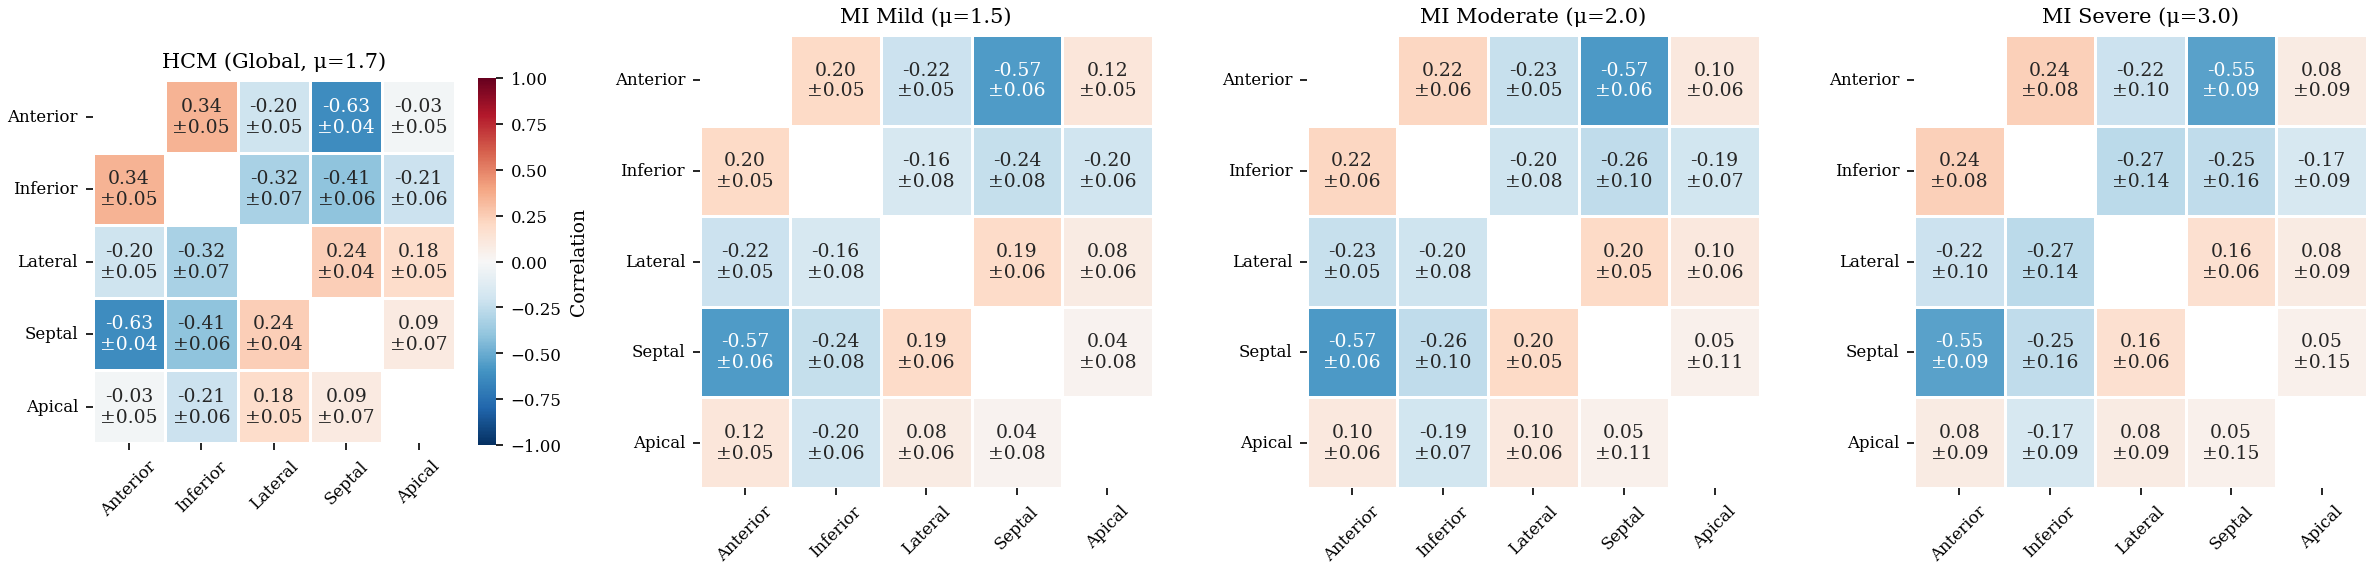

In [10]:
# 计算并展示 5×5 区域级相关（主图）
region_results = {}
for scenario, chains in all_chains.items():
    mean_c, std_c = aggregate_correlations(chains, level="region", region_method=REGION_METHOD)
    region_results[scenario] = (mean_c, std_c)

print("区域级后验相关矩阵（所有 100 个 sample 汇总）")
plot_scenario_heatmaps(
    region_results, level="region",
    # save_path=f"{OUTPUT_DIR}/region_corr_panel.png",
)

### 3b. 标准差面板（Supplementary）

标准差矩阵展示每个区域对的相关在 100 个 sample 之间的波动。
- **低 std** → 结构性相关（模型固有，与具体数据无关）→ equifinality 的直接证据
- **高 std** → 数据依赖性相关（某些观测下强，某些下弱）

注意：使用 PC1 方法后，Anterior↔Septal 的 std 依然很低，确认其为结构性补偿耦合。


相关矩阵的跨样本标准差（低 std = 结构性相关 = equifinality 证据）


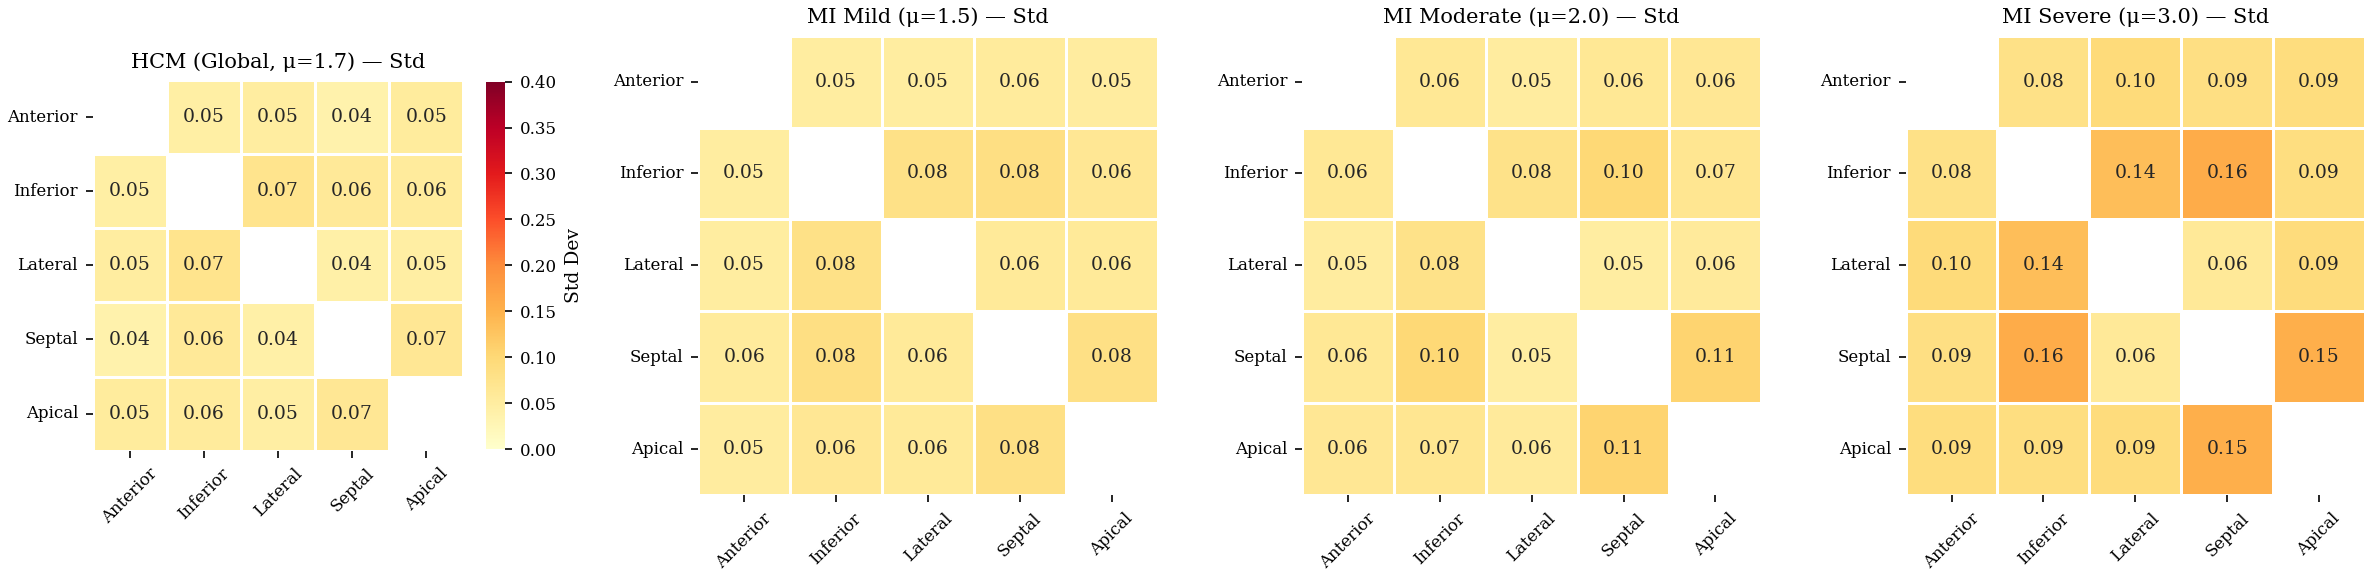

In [11]:
def plot_std_heatmaps(results, level="region", save_path=None):
    """标准差面板：展示相关的跨样本稳定性。YlOrRd 色彩映射，越红越不稳定。"""
    scenarios = list(results.keys())
    n = len(scenarios)
    ncols = min(n, 4)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.0 * ncols, 3.8 * nrows), squeeze=False)
    labels = REGION_LABELS if level == "region" else FULL_PARAM_LABELS
    for idx, scenario in enumerate(scenarios):
        row, col = divmod(idx, ncols)
        ax = axes[row, col]
        _, std_corr = results[scenario]
        data = std_corr.copy()
        np.fill_diagonal(data, np.nan)
        sns.heatmap(
            data, ax=ax, cmap="YlOrRd", vmin=0, vmax=0.4,
            annot=True, fmt=".2f",
            xticklabels=labels, yticklabels=labels,
            linewidths=0.5, linecolor="white",
            cbar=idx == 0,
            cbar_kws={"label": "Std Dev", "shrink": 0.8} if idx == 0 else {},
            square=True, mask=np.isnan(data),
        )
        ax.set_title(f"{SCENARIO_DISPLAY.get(scenario, scenario)} — Std")
        ax.tick_params(axis="x", rotation=45)
        ax.tick_params(axis="y", rotation=0)
    for idx in range(n, nrows * ncols):
        axes[*divmod(idx, ncols)].axis("off")
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path)
    plt.show()
    plt.close(fig)


print("相关矩阵的跨样本标准差（低 std = 结构性相关 = equifinality 证据）")
plot_std_heatmaps(region_results, 
                #   save_path=f"{OUTPUT_DIR}/region_corr_std_panel.png"
                  )

---
## 4. Per-Target 区域相关分析（MI 场景）

### 功能说明

对三个 MI 场景，将 100 个 sample 按病变区域分为 5 组（每组 20 个），分别计算 5×5 区域相关矩阵。

### 输出目的

**揭示病变区域的特异性耦合模式。** 例如当 Anterior 是病变区域时：
- Anterior 行/列的相关值是否比其他区域更高？（病变区域更难识别 → 更强 equifinality）
- 与 Anterior 相邻的区域（Lateral, Septal, Apical）是否比不相邻的（Inferior）表现出更强的耦合？
- 不同病变区域之间的模式是否一致？如果 target=Apical 的模式与其他4个明显不同，说明 Apical 的力学可识别性有独特特征。

每个 MI 严重程度生成一个 1×5 的面板图（5 个 target region），便于横向比较。


MI Mild (μ=1.5) — 按病变区域分组
每组 20 个 sample


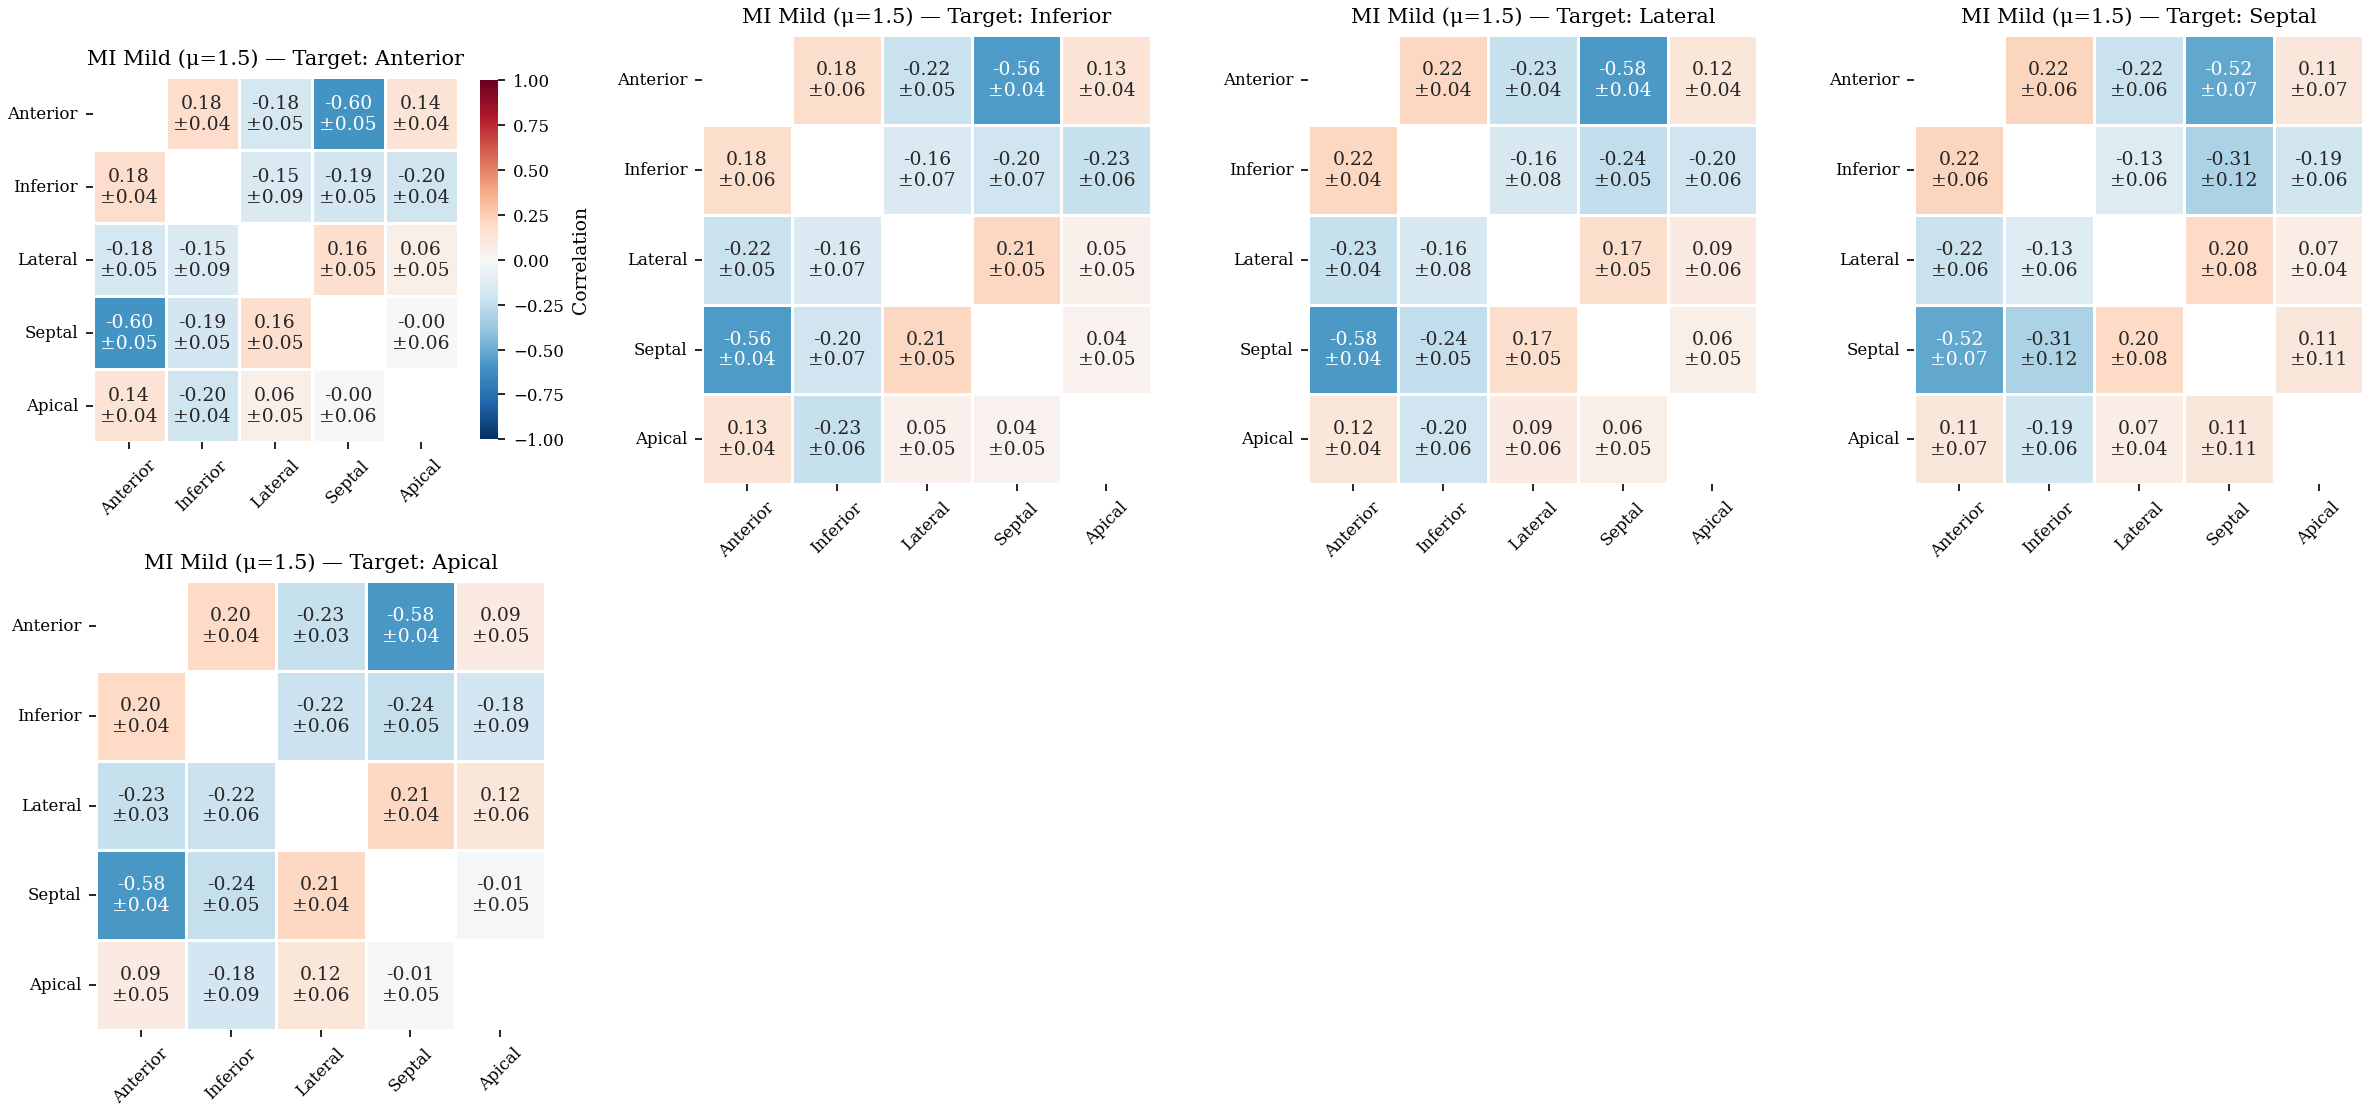


MI Moderate (μ=2.0) — 按病变区域分组
每组 20 个 sample


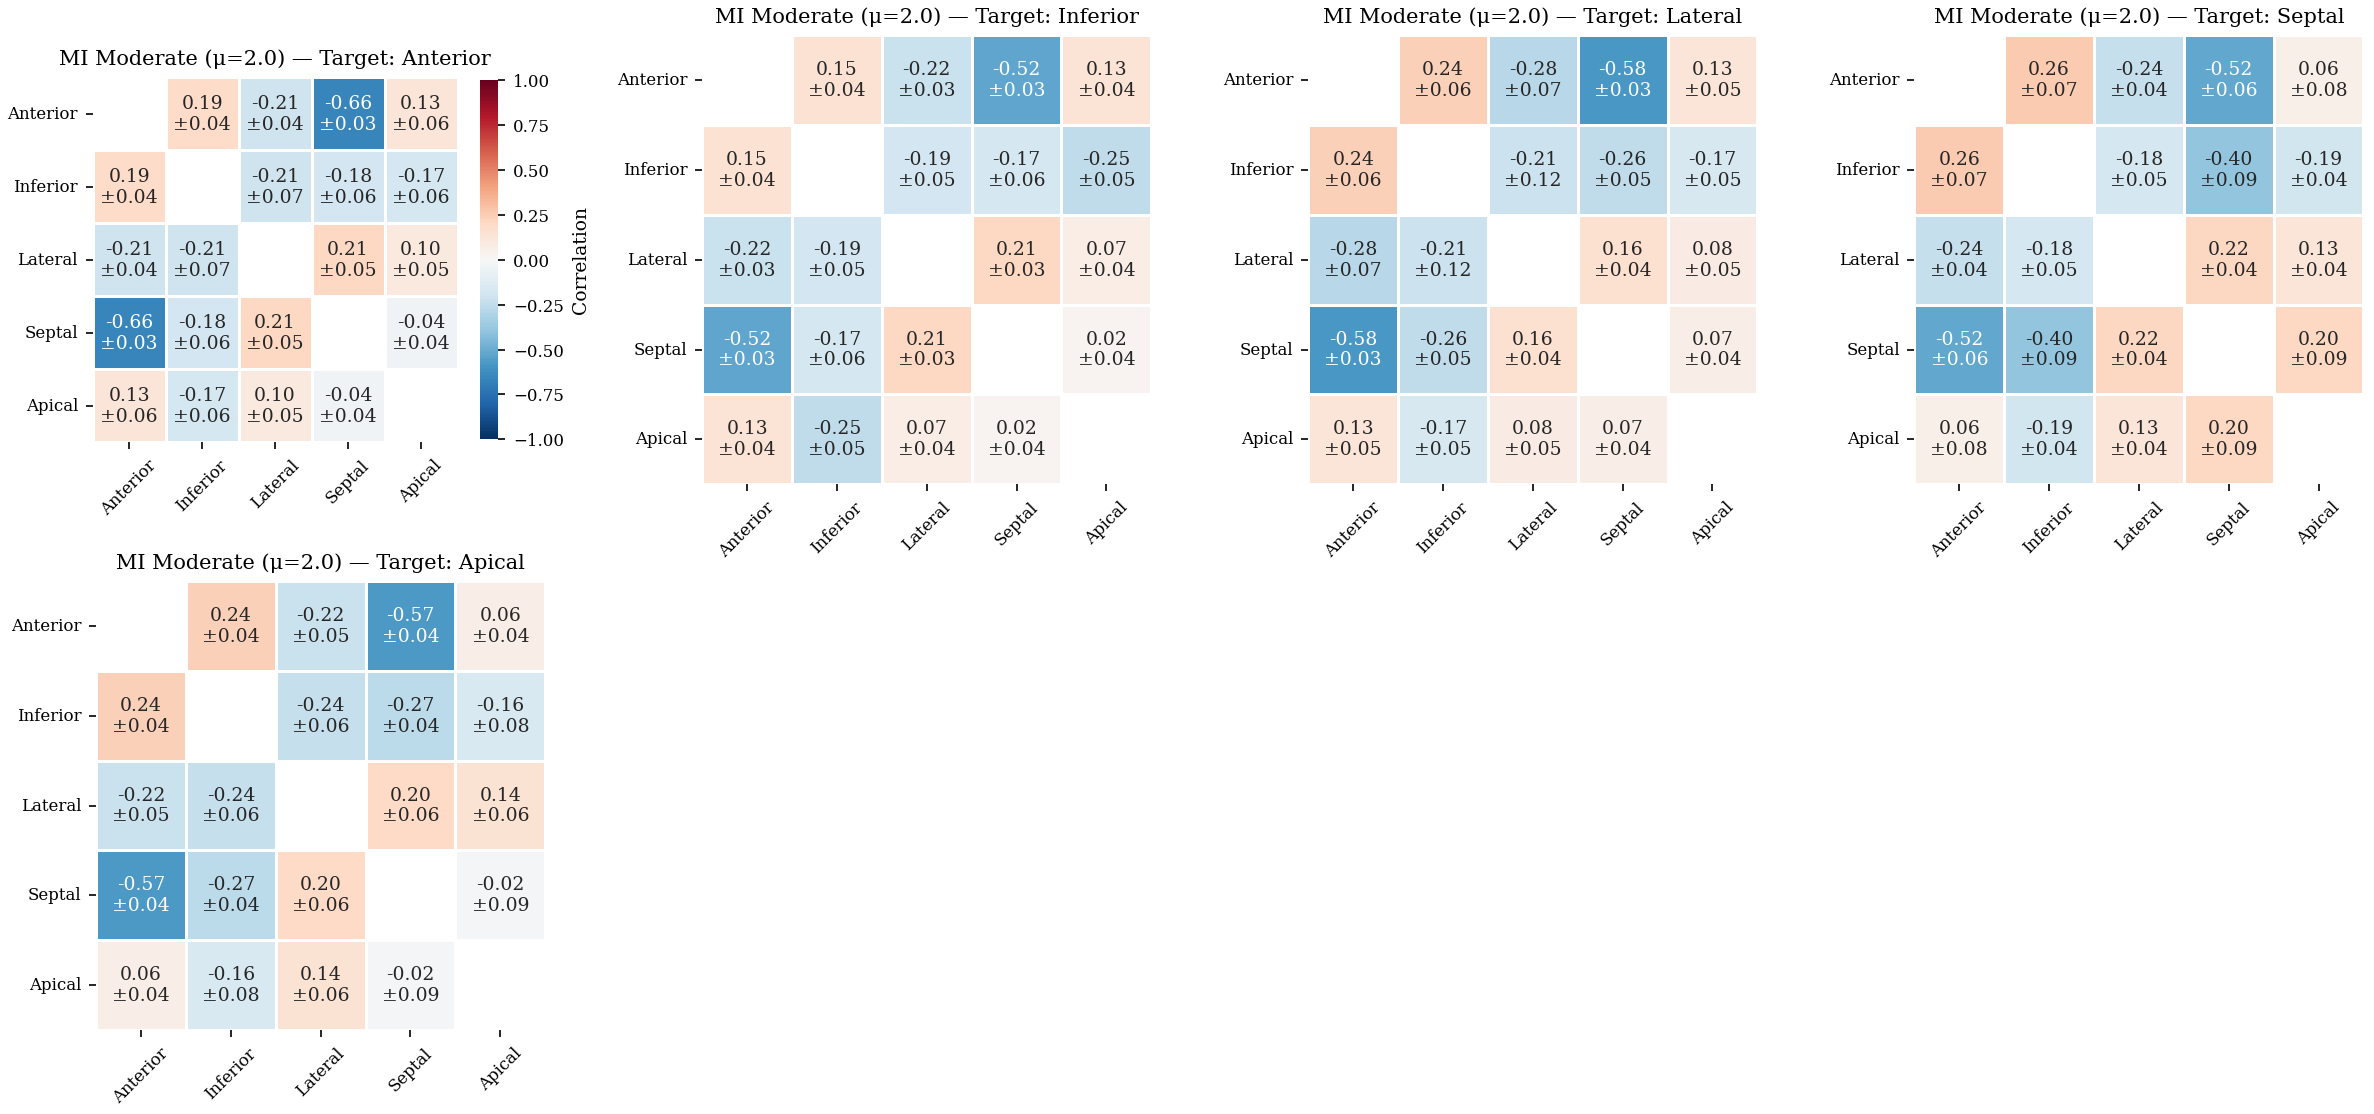


MI Severe (μ=3.0) — 按病变区域分组
每组 20 个 sample


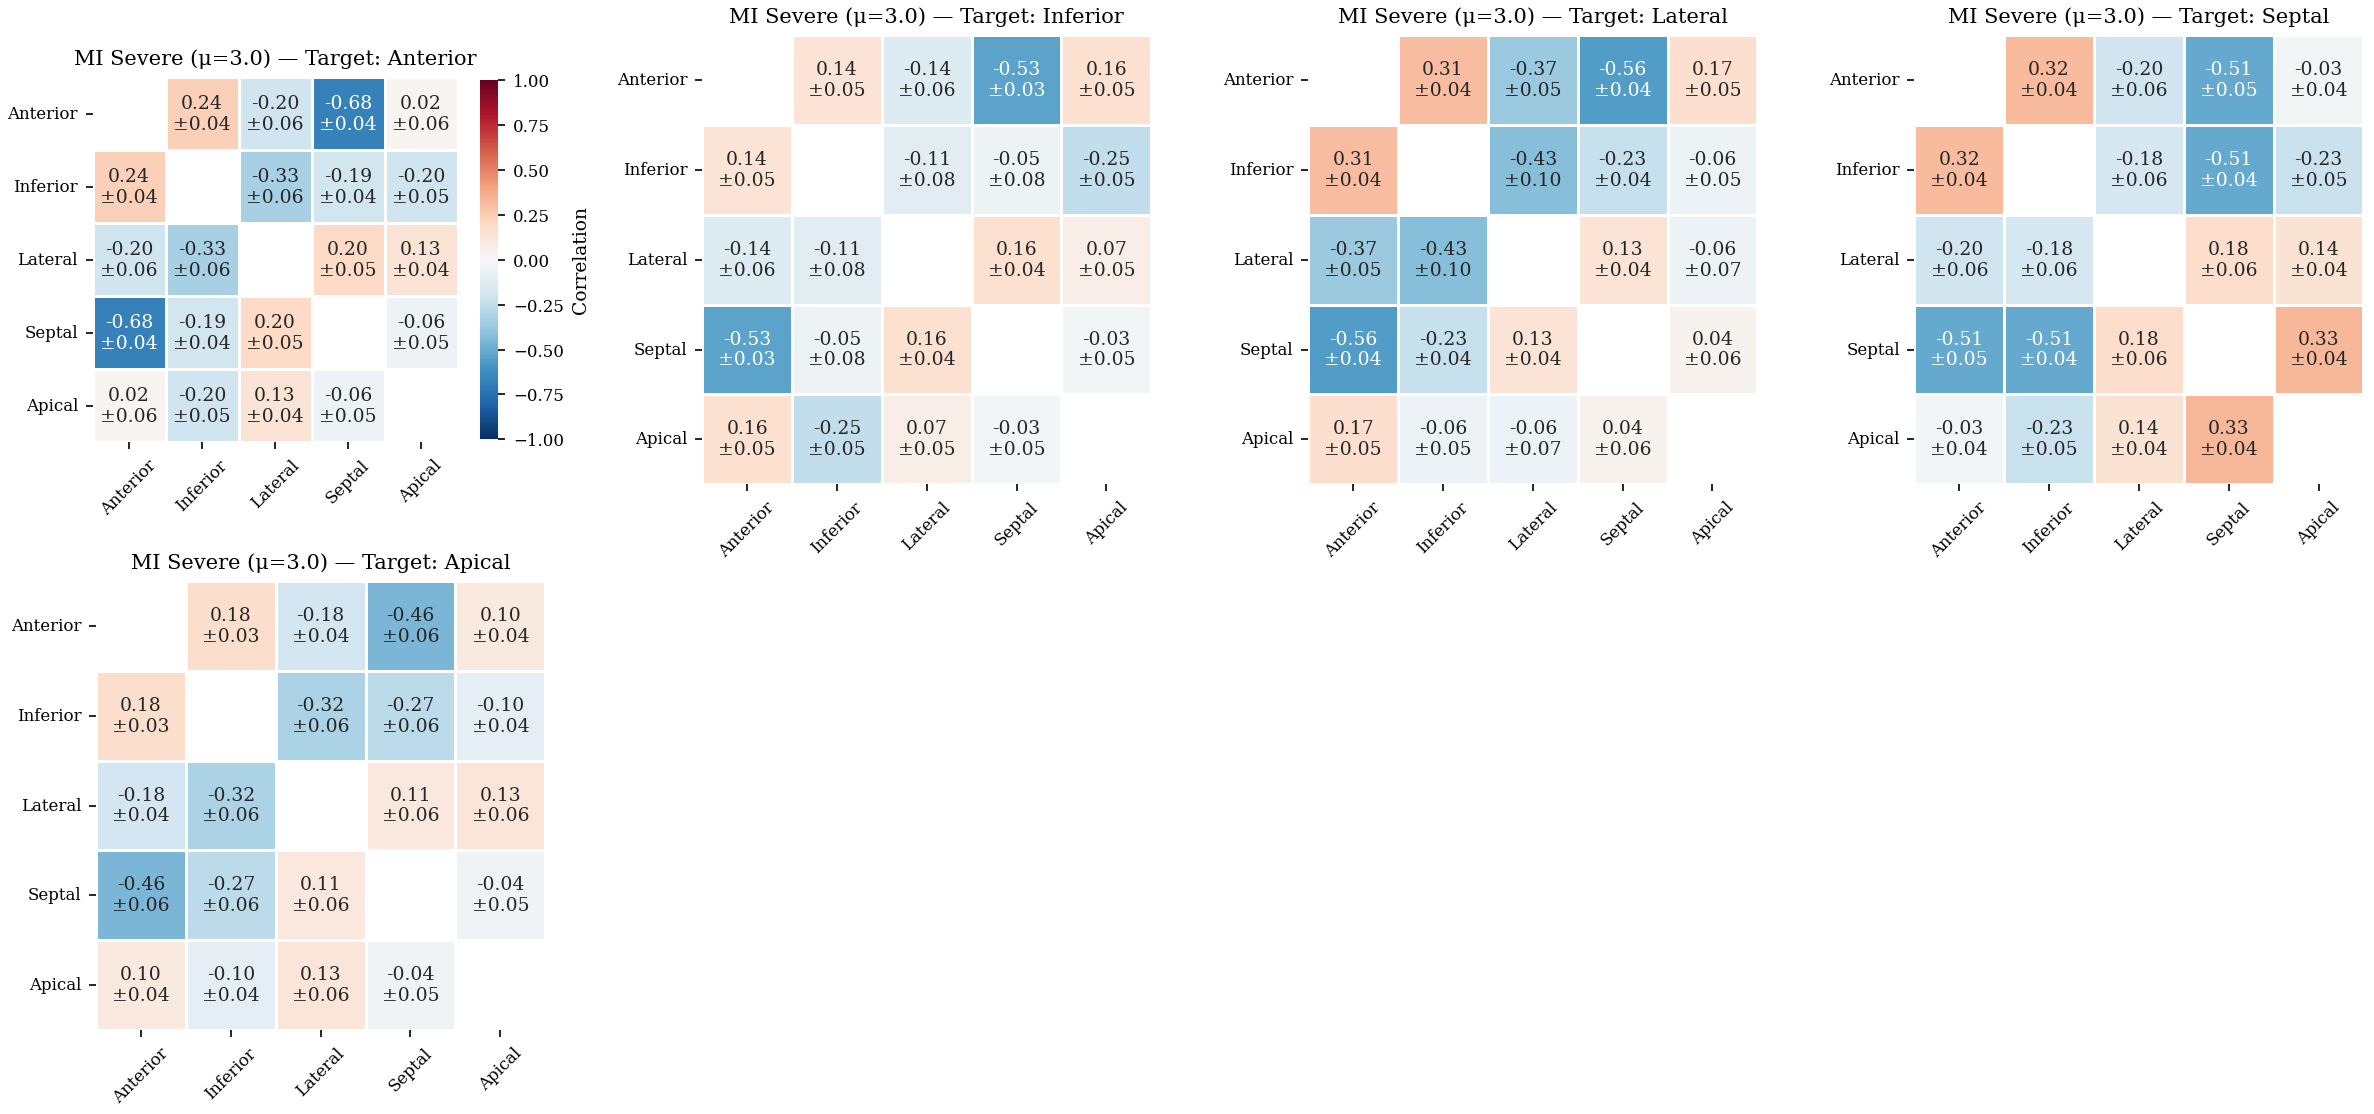

In [12]:
per_target_results = {}  # scenario → {target_region → (mean, std)}

for scenario in LOCAL_MI_SCENARIOS:
    if scenario not in all_chains:
        continue
    
    grouped = group_chains_by_target(all_chains[scenario], target_regions[scenario])
    per_target_results[scenario] = {}

    for target_r in range(N_REGIONS):
        target_chains = grouped[target_r]
        if not target_chains:
            continue
        mean_c, std_c = aggregate_correlations(target_chains, level="region", region_method=REGION_METHOD)
        per_target_results[scenario][target_r] = (mean_c, std_c)

    # 面板图：1×5，每个 target 一个子图
    target_panel = {
        f"Target: {REGION_LABELS[r]}": per_target_results[scenario][r]
        for r in range(N_REGIONS) if r in per_target_results[scenario]
    }

    print(f"\n{'='*60}")
    print(f"{SCENARIO_DISPLAY.get(scenario, scenario)} — 按病变区域分组")
    print(f"每组 {SAMPLES_PER_TARGET} 个 sample")
    print(f"{'='*60}")

    plot_scenario_heatmaps(
        target_panel, level="region",
        # save_path=f"{OUTPUT_DIR}/per_target_{scenario}.png",
        title_prefix=f"{SCENARIO_DISPLAY.get(scenario, scenario)} — ",
    )

---
## 5. Distance-Aligned 后验相关分析

### 功能说明

将 5×5 区域相关矩阵按 **"与病变区域的解剖距离"** 重新索引为 3×3 矩阵：
- **Dist 0（Target）**: 病变区域自身
- **Dist 1**: 直接相邻区域（距离 = 1）
- **Dist 2**: 不直接相邻区域（距离 = 2，如 Anterior ↔ Inferior 对侧壁）

同一距离的多个区域取平均，然后跨5组 target 做 pooling。

### 解剖距离分组示例

| Target | Dist 0 | Dist 1 | Dist 2 |
|--------|--------|--------|--------|
| Anterior | Anterior | Lateral, Septal, Apical | Inferior |
| Apical | Apical | Anterior, Inferior, Lateral, Septal | *（无）* |

**注意**: Apical 与所有 wall 段均为 Dist 1，没有 Dist 2 邻居。pooling 时用 `nanmean` 处理；另外提供排除 Apical 的版本（仅 pool 4 个 wall 段），得到无 NaN 的干净 3×3 矩阵。

### 输出目的

**提取距离依赖的通用 equifinality 模式**，消除具体区域编号的影响。关键问题：
- 后验相关是否随解剖距离递减？（距离越远耦合越弱 → 符合力学直觉）
- 还是距离无关？（全局耦合 → equifinality 不受局部性约束）
- 随病变严重程度增加，距离依赖关系如何变化？

In [13]:
def get_distance(region_a, region_b):
    """查表获取两个区域的解剖距离。"""
    return int(DISTANCE_MATRIX[region_a, region_b])


def get_distance_groups(target_region):
    """将所有区域按与 target 的距离分组。返回 dict[distance] → list of region indices。"""
    groups = {d: [] for d in range(MAX_DISTANCE + 1)}
    for r in range(N_REGIONS):
        groups[get_distance(target_region, r)].append(r)
    return groups


def align_by_distance(region_corr, target_region):
    """
    将 5×5 区域相关矩阵按解剖距离重索引为 3×3。
    同一距离的区域取平均；空组（如 Apical 无 Dist 2）标记为 NaN。
    """
    n_dist = MAX_DISTANCE + 1
    distance_groups = get_distance_groups(target_region)
    aligned = np.full((n_dist, n_dist), np.nan)
    for di in range(n_dist):
        for dj in range(n_dist):
            vals = [region_corr[ri, rj]
                    for ri in distance_groups[di]
                    for rj in distance_groups[dj]]
            if vals:
                aligned[di, dj] = np.mean(vals)
    return aligned


def _compute_region_corr_by_method(chain, region_method):
    """根据 region_method 选择合适的区域级相关计算方法。"""
    if region_method.startswith('pc1'):
        return compute_region_level_corr_pc1(chain, fixed_direction=(region_method == 'pc1_fixed'))
    else:
        return compute_region_level_corr(chain, method=region_method)


def compute_pooled_distance_aligned(scenario_chains, region_method="pc1_fixed", exclude_apical=False):
    """
    跨5组 target 的 distance-aligned 矩阵 pooling。
    用 nanmean/nanstd 正确处理 Apical 的缺失距离。
    exclude_apical=True 时仅 pool 4 个 wall 段。
    """
    all_aligned = []
    for target, chains in scenario_chains.items():
        if exclude_apical and target == 4:
            continue
        for chain in chains:
            rc = _compute_region_corr_by_method(chain, region_method)
            all_aligned.append(align_by_distance(rc, target))
    all_aligned = np.array(all_aligned)
    return np.nanmean(all_aligned, axis=0), np.nanstd(all_aligned, axis=0)


def plot_distance_aligned_heatmap(mean_aligned, std_aligned, title="", save_path=None):
    """Distance-aligned 3×3 热力图。"""
    max_dist = mean_aligned.shape[0]
    dist_labels = DISTANCE_LABELS[:max_dist]
    fig, ax = plt.subplots(figsize=(4.5, 4.0))
    norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
    data = _mask_diagonal(mean_aligned)
    annot_arr = np.empty_like(mean_aligned, dtype=object)
    for i in range(max_dist):
        for j in range(max_dist):
            if i == j:
                annot_arr[i, j] = ""
            elif np.isnan(mean_aligned[i, j]):
                annot_arr[i, j] = ""
            else:
                annot_arr[i, j] = f"{mean_aligned[i,j]:.2f}\n±{std_aligned[i,j]:.2f}"
    sns.heatmap(
        data, ax=ax, cmap="RdBu_r", norm=norm, annot=annot_arr, fmt="",
        xticklabels=dist_labels, yticklabels=dist_labels,
        linewidths=0.5, linecolor="white", square=True, mask=np.isnan(data),
        cbar_kws={"label": "Correlation", "shrink": 0.8},
    )
    ax.set_title(title)
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path)
    plt.show()
    plt.close(fig)


In [14]:
# 先展示各 target 的距离分组（验证解剖拓扑）
print("各 target region 的距离分组验证：\n")
for t in range(N_REGIONS):
    groups = get_distance_groups(t)
    names = {d: [REGION_LABELS[r] for r in rs] for d, rs in groups.items()}
    print(f"  Target = {REGION_LABELS[t]}:")
    for d in sorted(names):
        print(f"    Dist {d}: {names[d]}")

各 target region 的距离分组验证：

  Target = Anterior:
    Dist 0: ['Anterior']
    Dist 1: ['Lateral', 'Septal', 'Apical']
    Dist 2: ['Inferior']
  Target = Inferior:
    Dist 0: ['Inferior']
    Dist 1: ['Lateral', 'Septal', 'Apical']
    Dist 2: ['Anterior']
  Target = Lateral:
    Dist 0: ['Lateral']
    Dist 1: ['Anterior', 'Inferior', 'Apical']
    Dist 2: ['Septal']
  Target = Septal:
    Dist 0: ['Septal']
    Dist 1: ['Anterior', 'Inferior', 'Apical']
    Dist 2: ['Lateral']
  Target = Apical:
    Dist 0: ['Apical']
    Dist 1: ['Anterior', 'Inferior', 'Lateral', 'Septal']
    Dist 2: []



MI Mild (μ=1.5) — Distance-Aligned（含 Apical）
  Target ↔ Dist 1: -0.149 ± 0.098
  Target ↔ Dist 2: 0.183 ± 0.060
  Dist 1 ↔ Dist 2: -0.186 ± 0.067


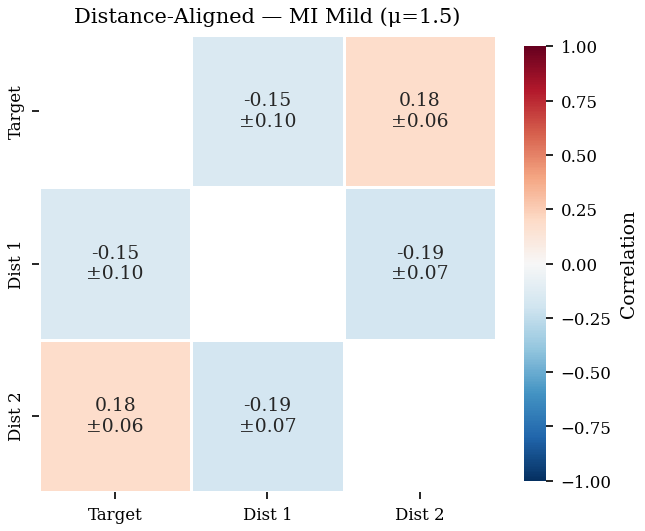


MI Moderate (μ=2.0) — Distance-Aligned（含 Apical）
  Target ↔ Dist 1: -0.164 ± 0.101
  Target ↔ Dist 2: 0.180 ± 0.046
  Dist 1 ↔ Dist 2: -0.185 ± 0.064


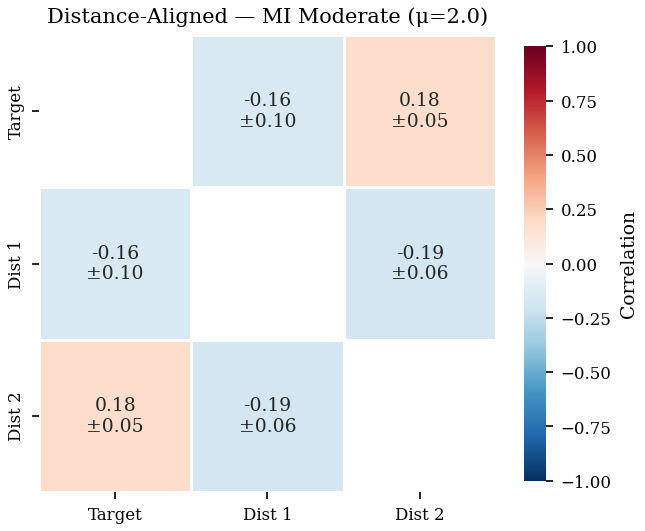


MI Severe (μ=3.0) — Distance-Aligned（含 Apical）
  Target ↔ Dist 1: -0.184 ± 0.123
  Target ↔ Dist 2: 0.175 ± 0.065
  Dist 1 ↔ Dist 2: -0.185 ± 0.075


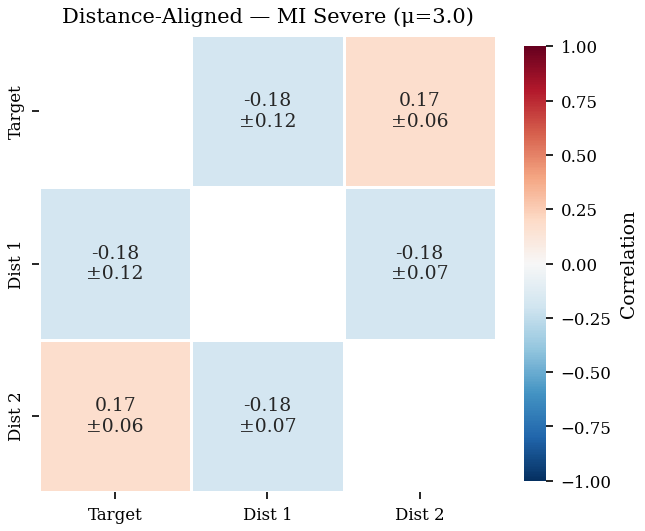

In [15]:
# 对每个 MI 场景计算 distance-aligned 矩阵
distance_results = {}

for scenario in LOCAL_MI_SCENARIOS:
    if scenario not in all_chains:
        continue
    grouped = group_chains_by_target(all_chains[scenario], target_regions[scenario])

    # 包含所有 5 个 target（Apical 的 Dist 2 为 NaN）
    mean_a, std_a = compute_pooled_distance_aligned(grouped, region_method=REGION_METHOD)
    distance_results[scenario] = (mean_a, std_a)

    print(f"\n{'='*60}")
    print(f"{SCENARIO_DISPLAY.get(scenario, scenario)} — Distance-Aligned（含 Apical）")
    print(f"  Target \u2194 Dist 1: {mean_a[0,1]:.3f} \u00b1 {std_a[0,1]:.3f}")
    if not np.isnan(mean_a[0, 2]):
        print(f"  Target \u2194 Dist 2: {mean_a[0,2]:.3f} \u00b1 {std_a[0,2]:.3f}")
        print(f"  Dist 1 \u2194 Dist 2: {mean_a[1,2]:.3f} \u00b1 {std_a[1,2]:.3f}")
    print(f"{'='*60}")

    plot_distance_aligned_heatmap(
        mean_a, std_a,
        title=f"Distance-Aligned — {SCENARIO_DISPLAY.get(scenario, scenario)}",
        # save_path=f"{OUTPUT_DIR}/distance_aligned_{scenario}.png",
    )

Distance-Aligned（排除 Apical，仅 4 个 wall 段 pooling）
Apical 与所有 wall 段均为 Dist 1，无 Dist 2，排除后结构更对称



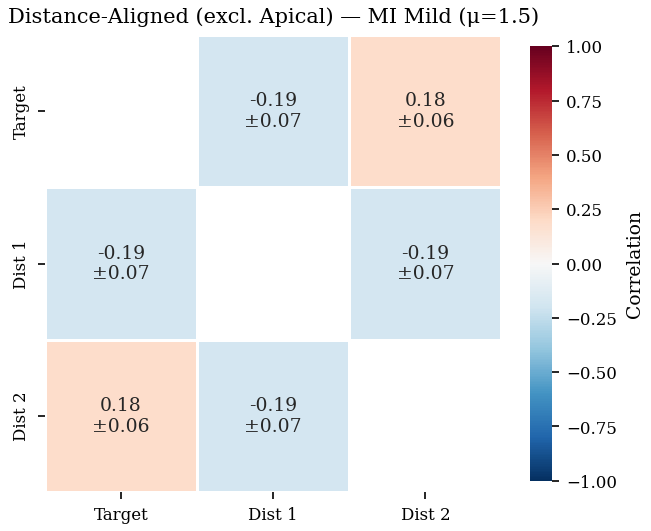

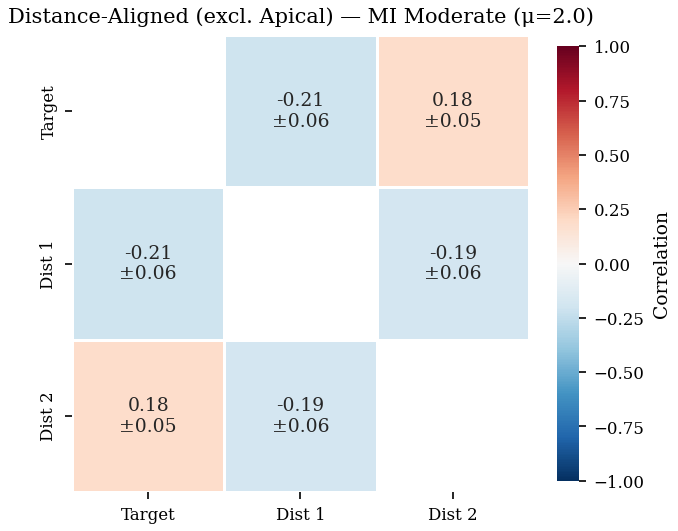

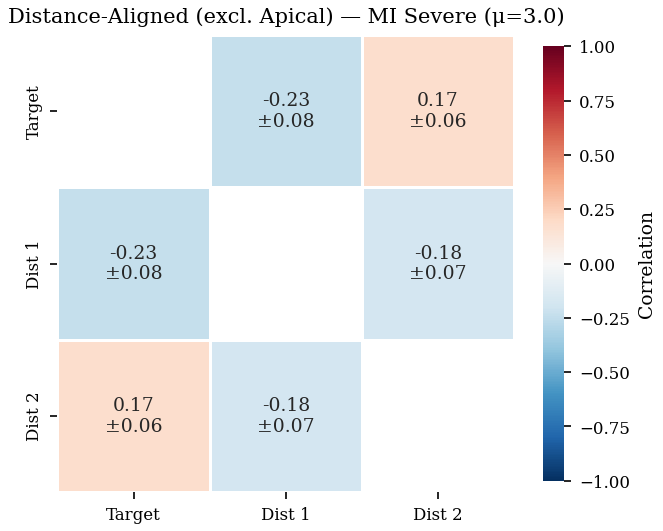

In [16]:
# 排除 Apical 的版本（4 个 wall 段，干净的 3×3 无 NaN）
print("Distance-Aligned（排除 Apical，仅 4 个 wall 段 pooling）")
print("Apical 与所有 wall 段均为 Dist 1，无 Dist 2，排除后结构更对称\n")

for scenario in LOCAL_MI_SCENARIOS:
    if scenario not in all_chains:
        continue
    grouped = group_chains_by_target(all_chains[scenario], target_regions[scenario])
    mean_a, std_a = compute_pooled_distance_aligned(
        grouped, region_method=REGION_METHOD, exclude_apical=True
    )
    plot_distance_aligned_heatmap(
        mean_a, std_a,
        title=f"Distance-Aligned (excl. Apical) — {SCENARIO_DISPLAY.get(scenario, scenario)}",
        # save_path=f"{OUTPUT_DIR}/distance_aligned_{scenario}_no_apical.png",
    )

### 5b. Distance-Aligned 跨严重程度面板

将三个 MI 等级的 distance-aligned 矩阵（排除 Apical）并排展示，直观观察 **"随病变加重，距离依赖的耦合如何演变"**。

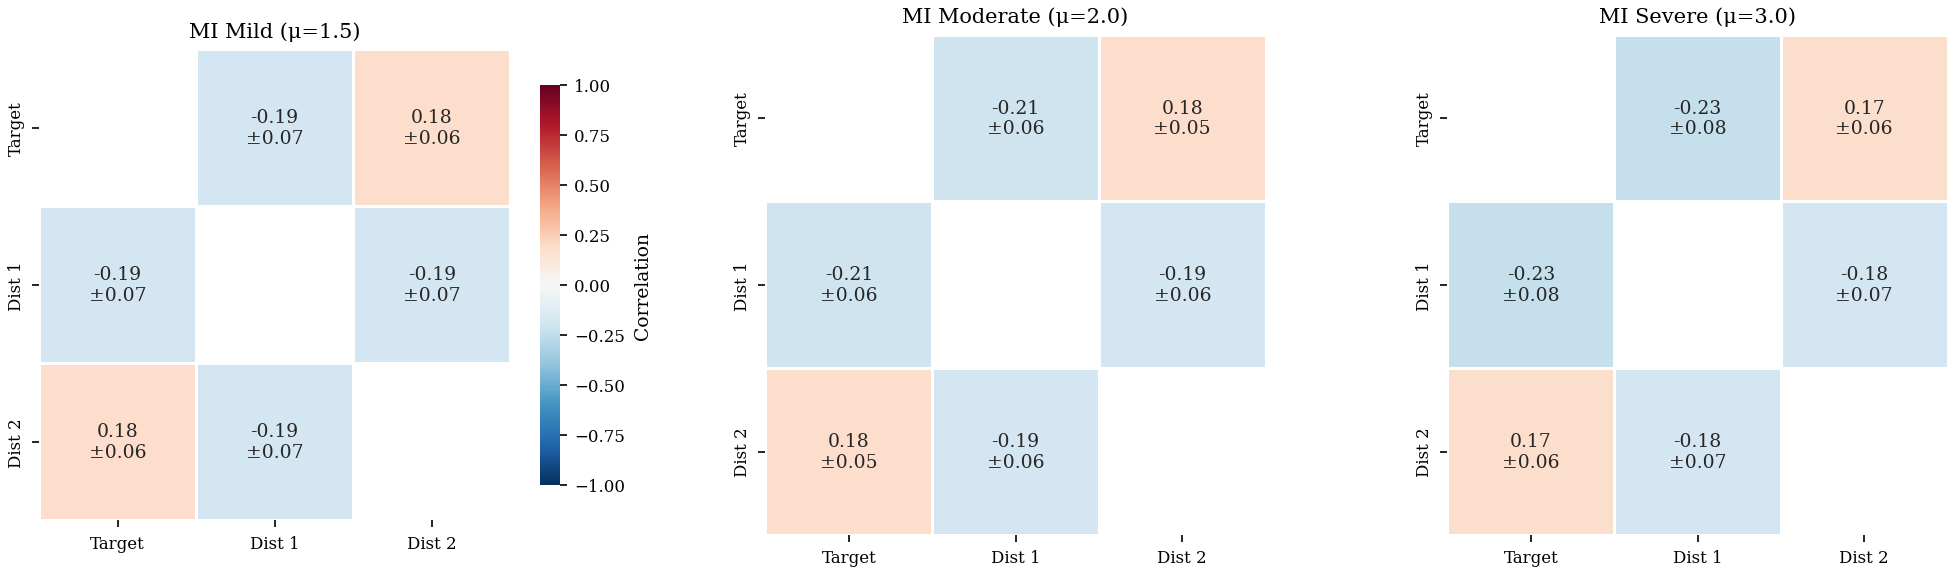

In [17]:
# Distance-aligned 面板：MI_1 / MI_2 / MI_3 并排
dist_panel = {}
for scenario in LOCAL_MI_SCENARIOS:
    if scenario not in all_chains:
        continue
    grouped = group_chains_by_target(all_chains[scenario], target_regions[scenario])
    m, s = compute_pooled_distance_aligned(grouped, region_method=REGION_METHOD, exclude_apical=True)
    dist_panel[scenario] = (m, s)

if dist_panel:
    n_panel = len(dist_panel)
    n_dist = MAX_DISTANCE + 1
    fig, axes = plt.subplots(1, n_panel, figsize=(4.5 * n_panel, 4.0))
    if n_panel == 1:
        axes = [axes]
    norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

    for idx, (scenario, (mc, sc)) in enumerate(dist_panel.items()):
        ax = axes[idx]
        data = _mask_diagonal(mc)
        annot_arr = np.empty_like(mc, dtype=object)
        for i in range(n_dist):
            for j in range(n_dist):
                if i == j or np.isnan(mc[i, j]):
                    annot_arr[i, j] = ""
                else:
                    annot_arr[i, j] = f"{mc[i,j]:.2f}\n\u00b1{sc[i,j]:.2f}"
        sns.heatmap(
            data, ax=ax, cmap="RdBu_r", norm=norm,
            annot=annot_arr, fmt="",
            xticklabels=DISTANCE_LABELS, yticklabels=DISTANCE_LABELS,
            linewidths=0.5, linecolor="white", square=True, mask=np.isnan(data),
            cbar=idx == 0,
            cbar_kws={"label": "Correlation", "shrink": 0.8} if idx == 0 else {},
        )
        ax.set_title(SCENARIO_DISPLAY.get(scenario, scenario))

    fig.tight_layout()
    # fig.savefig(f"{OUTPUT_DIR}/distance_aligned_panel.png")
    # print(f"Saved: {OUTPUT_DIR}/distance_aligned_panel.png")
    plt.show()
    plt.close(fig)

---
## 6. 严重程度趋势：柱状图

### 功能说明

对每一对区域 (Region i, Region j)，用柱状图展示其后验相关在不同 scenario 之间的变化，error bar 为跨 100 个 sample 的标准差。

### 输出目的

**量化 equifinality 与疾病严重程度的关系：**
- 如果某个区域对的相关随 MI_1 → MI_2 → MI_3 单调递增，说明病变越重，这两个区域越难区分
- HCM（全局病变）的相关模式与 MI（局部病变）有本质区别吗？
- 是否存在某些区域对始终低相关（即使在严重病变下也能独立识别）？

此处生成两组柱状图：仅 MI 三级对比，以及包含 HCM 的全景对比。

In [18]:
def plot_corr_comparison_bar(results, region_i=0, region_j=1, level="region", save_path=None):
    """
    柱状图：指定区域对的相关在各 scenario 间的比较。
    高度 = 均值，error bar = 跨样本 std。
    """
    scenarios = list(results.keys())
    means = [results[s][0][region_i, region_j] for s in scenarios]
    stds = [results[s][1][region_i, region_j] for s in scenarios]
    display = [SCENARIO_DISPLAY.get(s, s) for s in scenarios]

    fig, ax = plt.subplots(figsize=(5, 3.5))
    colors = sns.color_palette("coolwarm", len(scenarios))
    ax.bar(display, means, yerr=stds, capsize=4, color=colors, edgecolor="black", linewidth=0.5)
    ax.axhline(0, color="grey", linewidth=0.5, linestyle="--")
    ax.set_ylabel("Posterior Correlation")
    label_i = REGION_LABELS[region_i] if level == "region" else FULL_PARAM_LABELS[region_i]
    label_j = REGION_LABELS[region_j] if level == "region" else FULL_PARAM_LABELS[region_j]
    ax.set_title(f"Correlation: {label_i} \u2194 {label_j}")
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path)
    plt.show()
    plt.close(fig)

MI 严重程度趋势（MI_1 → MI_2 → MI_3）


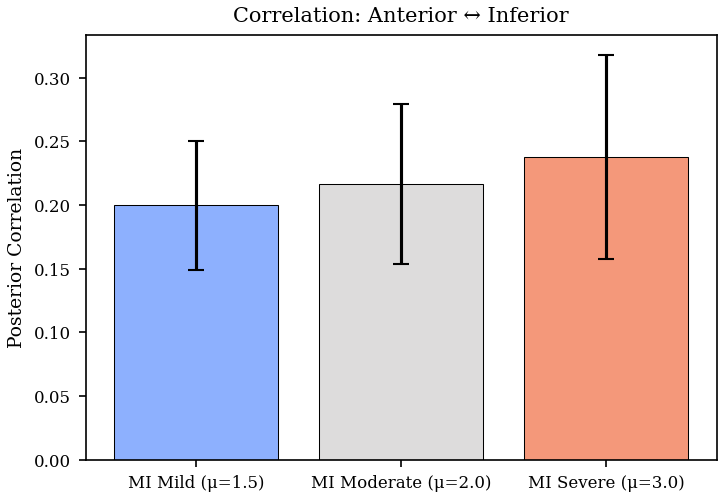

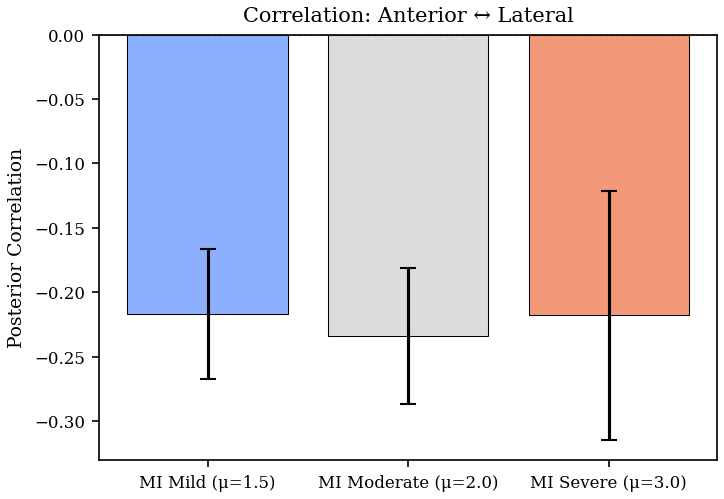

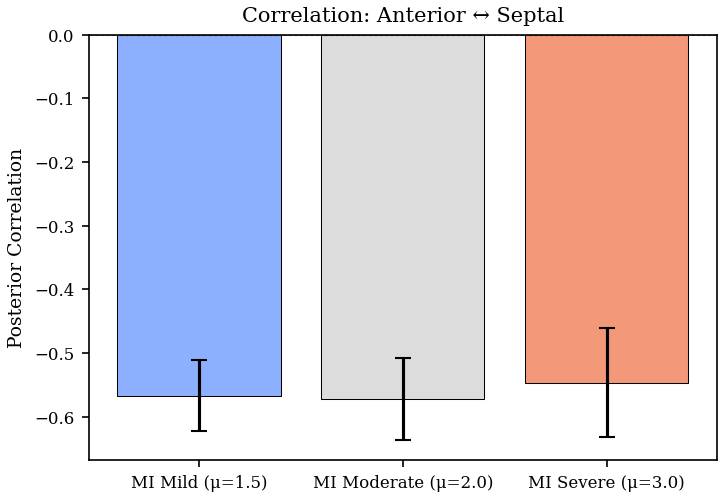

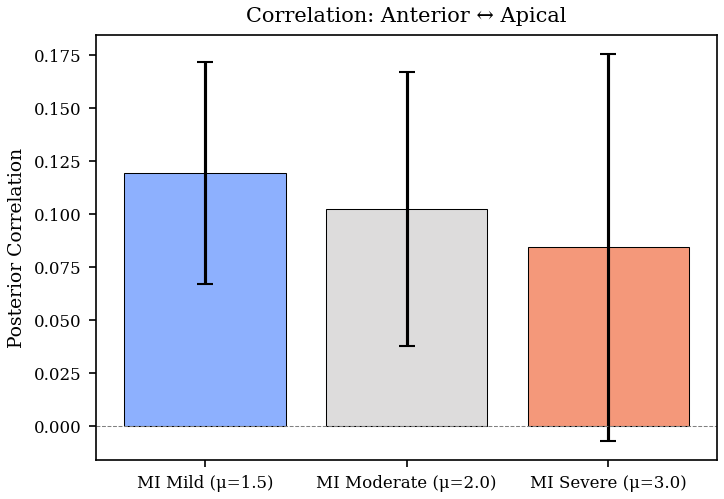

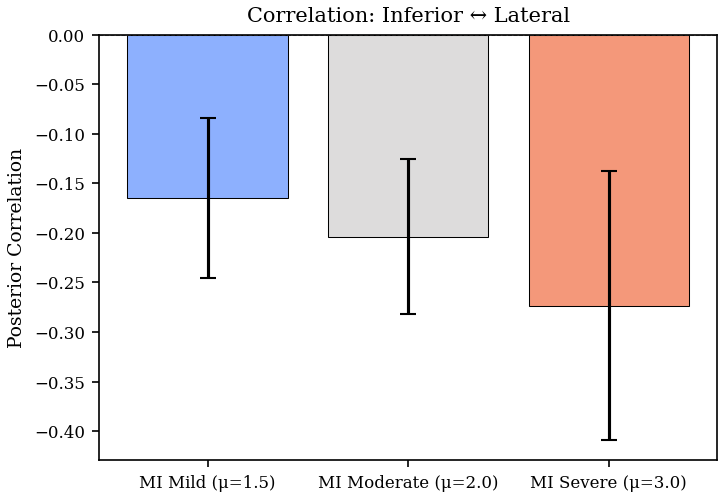

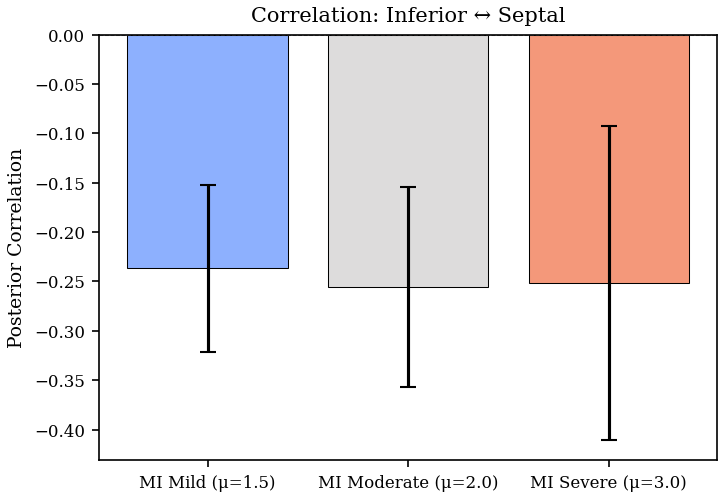

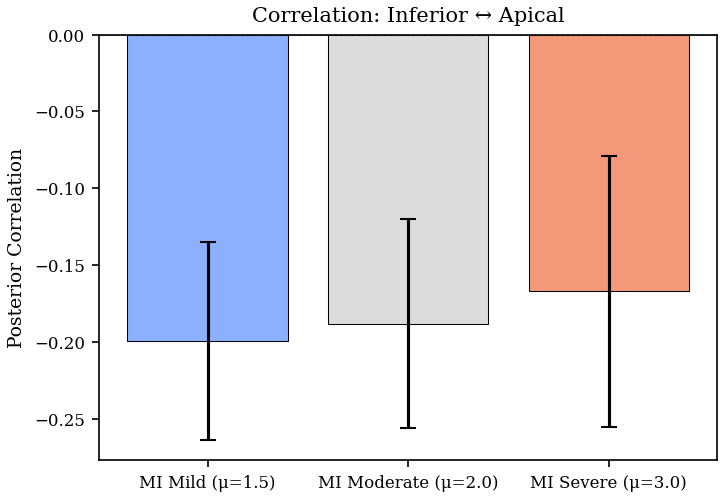

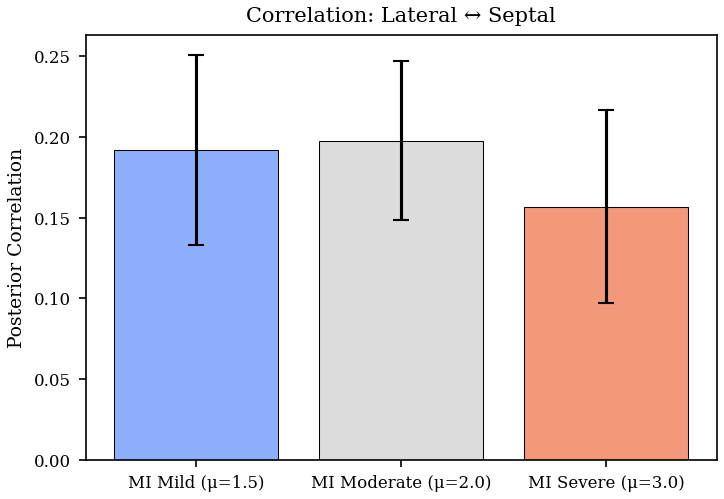

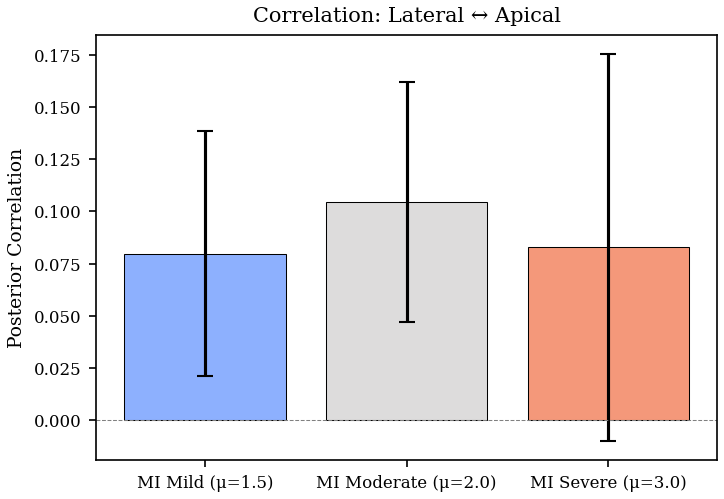

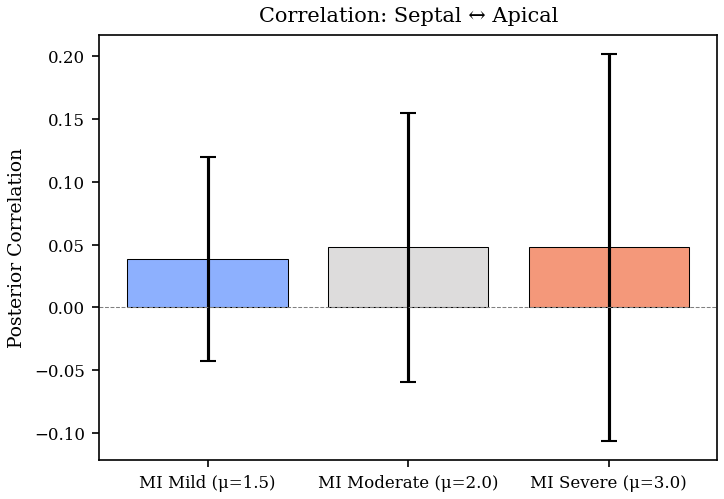

In [19]:
# 6a. 仅 MI 三级对比
mi_results = {s: region_results[s] for s in LOCAL_MI_SCENARIOS if s in region_results}

if mi_results:
    print("MI 严重程度趋势（MI_1 → MI_2 → MI_3）")
    print("="*60)
    for i in range(N_REGIONS):
        for j in range(i + 1, N_REGIONS):
            plot_corr_comparison_bar(
                mi_results, region_i=i, region_j=j, level="region",
                # save_path=f"{OUTPUT_DIR}/trend_{REGION_LABELS_SHORT[i]}_{REGION_LABELS_SHORT[j]}.png",
            )

全景趋势（HCM + MI_1 + MI_2 + MI_3）


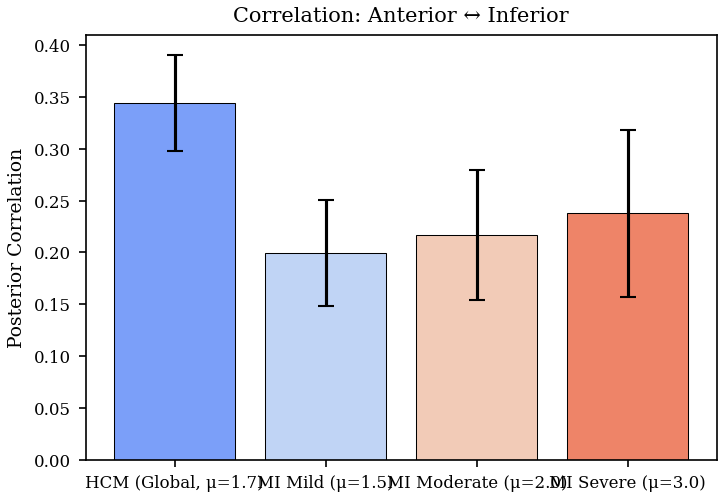

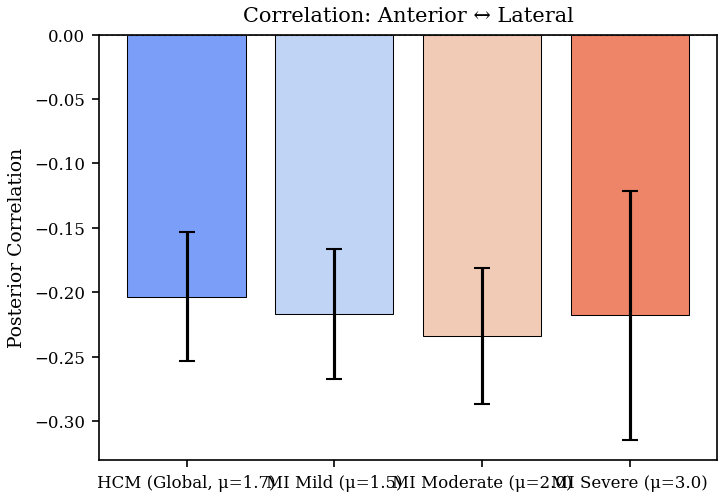

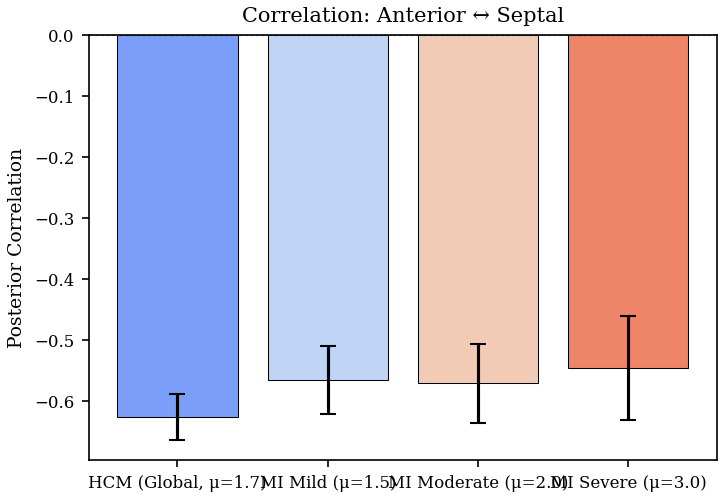

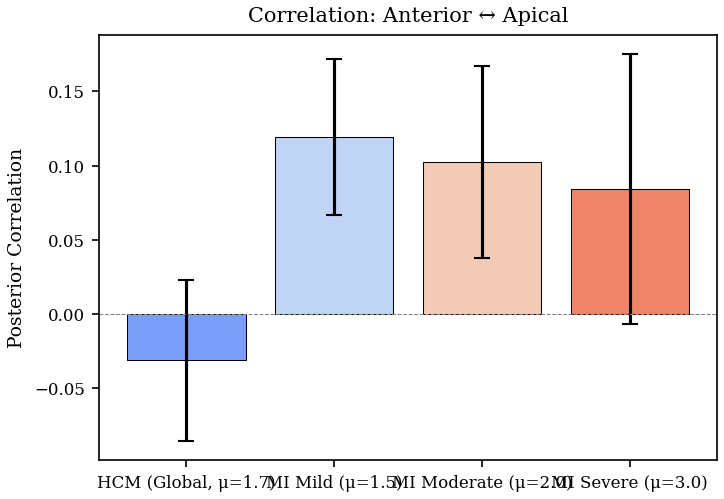

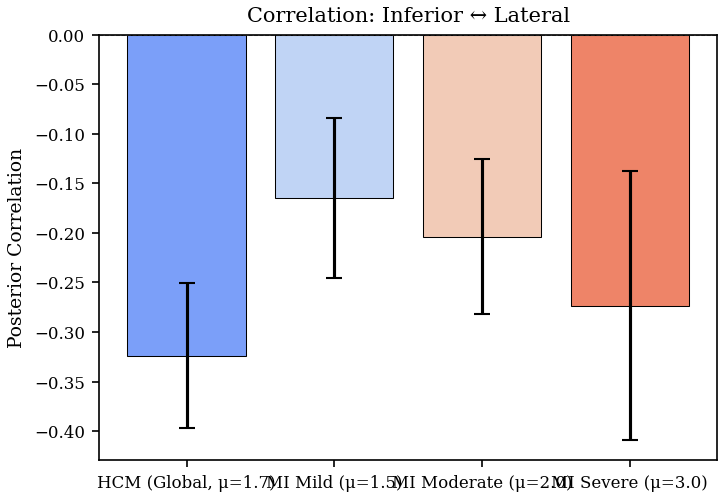

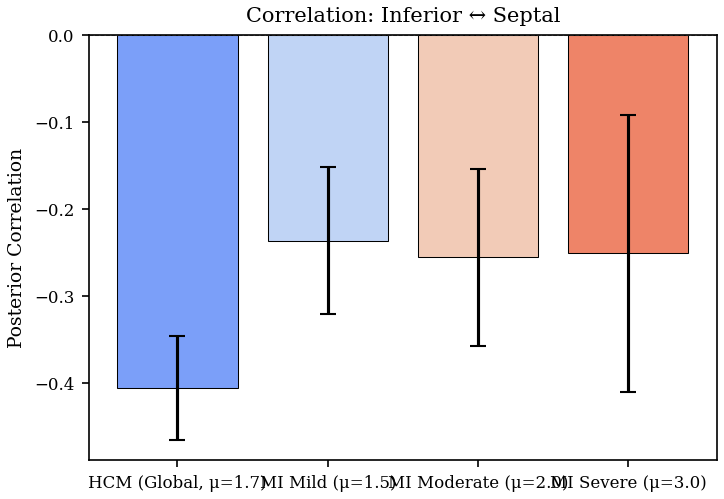

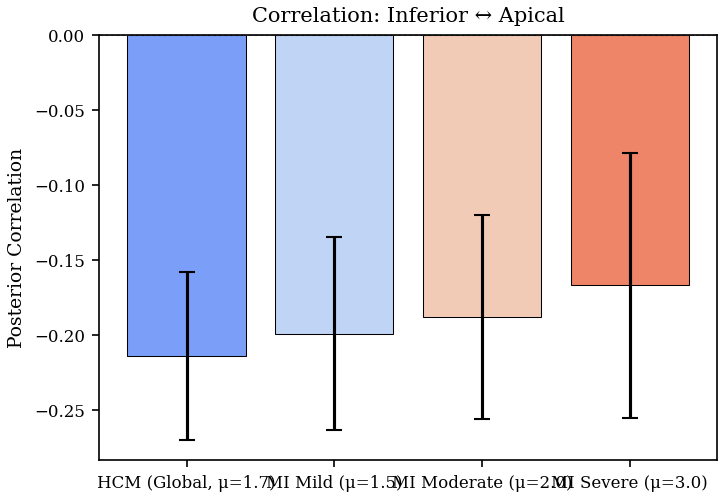

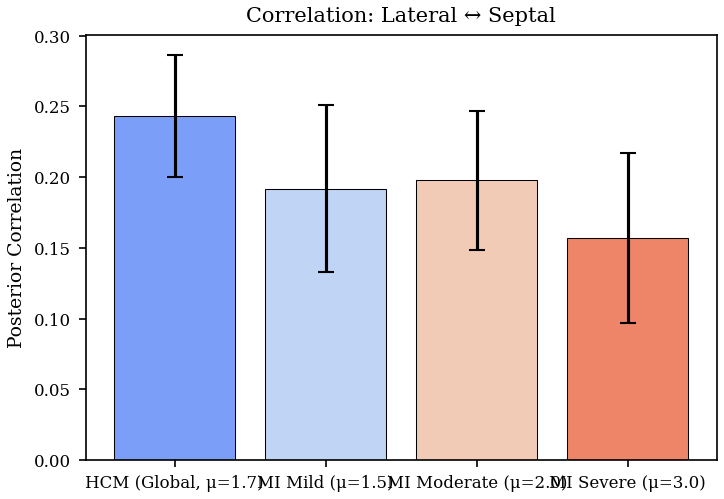

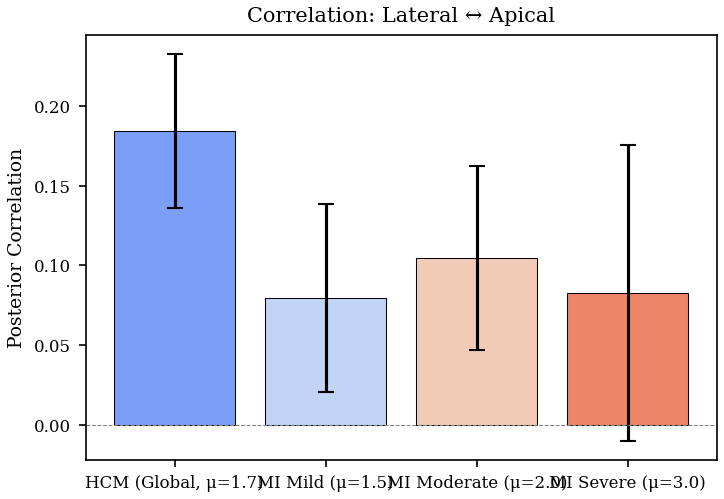

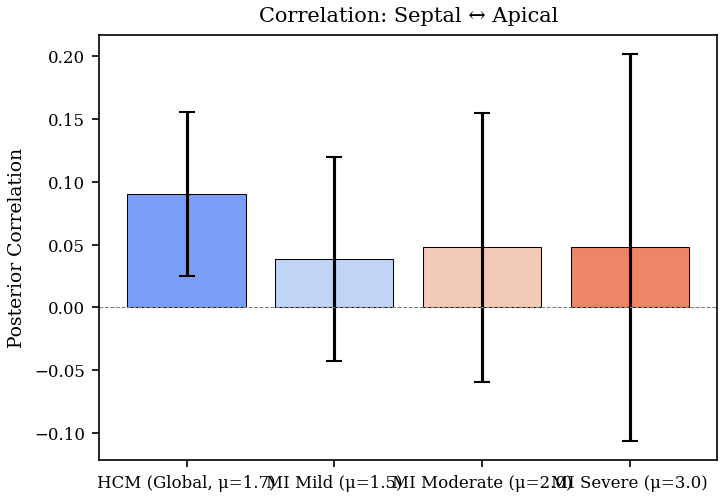

In [20]:
# 6b. 包含 HCM 的全景对比
all_for_trend = {s: region_results[s] for s in SCENARIOS if s in region_results}

if len(all_for_trend) > 1:
    print("全景趋势（HCM + MI_1 + MI_2 + MI_3）")
    print("="*60)
    for i in range(N_REGIONS):
        for j in range(i + 1, N_REGIONS):
            plot_corr_comparison_bar(
                all_for_trend, region_i=i, region_j=j, level="region",
                # save_path=f"{OUTPUT_DIR}/trend_all_{REGION_LABELS_SHORT[i]}_{REGION_LABELS_SHORT[j]}.png",
            )

---
## 7. 稳定相关筛选

### 功能说明

在每个 scenario 中，筛选满足以下两个条件的区域对：
- **强度**: |mean correlation| ≥ 阈值（默认 0.3）
- **稳定性**: std across samples ≤ 阈值（默认 0.1）

### 输出目的

**这些是你论文中可以 confident 报告的 "结构性 equifinality" 区域对。** 高均值说明耦合强，低标准差说明不依赖具体观测数据——它们是模型/几何结构内在导致的，而非数据噪声的产物。如果某个区域对在所有 scenario 中都稳定出现，说明该 equifinality 是力学模型的固有属性。

In [21]:
def identify_stable_correlations(mean_corr, std_corr, min_abs_corr=0.3, max_std=0.1):
    """
    筛选 |mean| ≥ min_abs_corr 且 std ≤ max_std 的区域对。
    返回布尔矩阵，True 的位置是强且稳定的相关。
    """
    return (np.abs(mean_corr) >= min_abs_corr) & (std_corr <= max_std)


print("稳定相关筛选 (|mean| \u2265 0.3, std \u2264 0.1)")
print("="*60)

for scenario, (mean_c, std_c) in region_results.items():
    mask = identify_stable_correlations(mean_c, std_c)
    n_stable = mask.sum() - N_REGIONS  # 排除对角线
    display = SCENARIO_DISPLAY.get(scenario, scenario)

    if n_stable > 0:
        print(f"\n  {display}: {n_stable // 2} 对稳定相关")
        for i in range(N_REGIONS):
            for j in range(i + 1, N_REGIONS):
                if mask[i, j]:
                    print(f"    {REGION_LABELS[i]} \u2194 {REGION_LABELS[j]}: "
                          f"{mean_c[i,j]:.3f} \u00b1 {std_c[i,j]:.3f}")
    else:
        print(f"\n  {display}: 无稳定相关被检出")

print("\n" + "-"*60)
print("提示: 如果无稳定相关被检出，可适当放宽阈值（降低 min_abs_corr 或提高 max_std）")
print("或检查 Step 3 的标准差面板，手动识别值得报告的区域对。")

稳定相关筛选 (|mean| ≥ 0.3, std ≤ 0.1)

  HCM (Global, μ=1.7): 4 对稳定相关
    Anterior ↔ Inferior: 0.344 ± 0.047
    Anterior ↔ Septal: -0.627 ± 0.037
    Inferior ↔ Lateral: -0.324 ± 0.073
    Inferior ↔ Septal: -0.405 ± 0.060

  MI Mild (μ=1.5): 1 对稳定相关
    Anterior ↔ Septal: -0.567 ± 0.056

  MI Moderate (μ=2.0): 1 对稳定相关
    Anterior ↔ Septal: -0.572 ± 0.064

  MI Severe (μ=3.0): 1 对稳定相关
    Anterior ↔ Septal: -0.546 ± 0.085

------------------------------------------------------------
提示: 如果无稳定相关被检出，可适当放宽阈值（降低 min_abs_corr 或提高 max_std）
或检查 Step 3 的标准差面板，手动识别值得报告的区域对。


---
## 8. Fisher z-test: 场景间统计比较

### 功能说明

对两个 scenario 的均值相关矩阵做逐元素的 Fisher z 变换检验：
1. 将 Pearson 相关系数 r 转为 Fisher z = arctanh(r)
2. 计算两组 z 值之差除以标准误 SE = √(2/(n-3))
3. |z| > 1.96 对应 p < 0.05

### 输出目的

**检验不同 scenario 间后验耦合结构是否有统计显著差异。** 两组对比：
- **MI_1 vs MI_3**（最轻 vs 最重局部病变）：病变加重是否显著改变了 equifinality？
- **MI_1 vs HCM**（局部 vs 全局病变）：病变模式（集中 vs 弥漫）对后验耦合的影响是否显著不同？

**注意**: `n_eff` 应设为 thinning 后的有效 MCMC 样本量，非原始 chain 长度。如果 chain 有自相关，有效样本量远小于总迭代次数。

In [22]:
def fisher_z_test(corr_a, corr_b, n):
    """
    逐元素 Fisher z-test，检验两个相关矩阵的差异。
    n = 有效 MCMC 样本量（thinning 后）。
    返回 z 统计量矩阵，|z| > 1.96 对应 p < 0.05。
    """
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        za = np.arctanh(np.clip(corr_a, -0.999, 0.999))
        zb = np.arctanh(np.clip(corr_b, -0.999, 0.999))
    se = np.sqrt(2.0 / (n - 3))
    return (za - zb) / se


# ── 执行检验 ──
N_EFF = 500  # <-- 修改为你的有效 MCMC 样本量

comparisons = [
    ("MI_1", "MI_3", "MI Mild vs MI Severe"),
    ("MI_1", "HCM", "MI Mild (Local) vs HCM (Global)"),
]

for s_a, s_b, label in comparisons:
    if s_a not in region_results or s_b not in region_results:
        print(f"\u26a0 Skipping {label}: data not available")
        continue

    z_scores = fisher_z_test(region_results[s_a][0], region_results[s_b][0], n=N_EFF)
    sig = np.abs(z_scores) > 1.96
    np.fill_diagonal(sig, False)

    print(f"\n{'='*60}")
    print(f"Fisher z-test: {label}  (n_eff = {N_EFF})")
    print(f"{'='*60}")

    found = False
    for i in range(N_REGIONS):
        for j in range(i + 1, N_REGIONS):
            if sig[i, j]:
                found = True
                corr_a_val = region_results[s_a][0][i, j]
                corr_b_val = region_results[s_b][0][i, j]
                print(f"  {REGION_LABELS[i]} \u2194 {REGION_LABELS[j]}:")
                print(f"    {SCENARIO_DISPLAY[s_a]}: {corr_a_val:.3f}")
                print(f"    {SCENARIO_DISPLAY[s_b]}: {corr_b_val:.3f}")
                print(f"    z = {z_scores[i,j]:.2f}, p < 0.05")

    if not found:
        print("  无显著差异 (所有 |z| < 1.96)")


Fisher z-test: MI Mild vs MI Severe  (n_eff = 500)
  无显著差异 (所有 |z| < 1.96)

Fisher z-test: MI Mild (Local) vs HCM (Global)  (n_eff = 500)
  Anterior ↔ Inferior:
    MI Mild (μ=1.5): 0.200
    HCM (Global, μ=1.7): 0.344
    z = -2.46, p < 0.05
  Anterior ↔ Apical:
    MI Mild (μ=1.5): 0.119
    HCM (Global, μ=1.7): -0.031
    z = 2.38, p < 0.05
  Inferior ↔ Lateral:
    MI Mild (μ=1.5): -0.165
    HCM (Global, μ=1.7): -0.324
    z = 2.67, p < 0.05
  Inferior ↔ Septal:
    MI Mild (μ=1.5): -0.237
    HCM (Global, μ=1.7): -0.405
    z = 2.98, p < 0.05


---
## 9. 结果汇总

以下 cell 汇总所有输出文件和关键发现。

In [ ]:
# 列出所有生成的图像文件
output_path = Path(OUTPUT_DIR)
files = sorted(output_path.glob("*.png"))

print(f"\u2705 共生成 {len(files)} 个图像文件：\n")
for f in files:
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:50s} ({size_kb:.0f} KB)")

print(f"\n输出目录: {output_path.resolve()}")
print("\n" + "="*60)
print("分析完成。")
print("="*60)